In [1]:
# ============================================================
# PHASE 8 — EXPANDED BIOLOGICAL VALIDATION
# ============================================================

!pip install -q gprofiler-official openpyxl

In [2]:
# ============================================================
# IMPORTS + PATHS
# ============================================================

import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from gprofiler import GProfiler

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 250)
pd.set_option("display.max_colwidth", 300)

SEED = 42
np.random.seed(SEED)

# ============================================================
# PROJECT PATHS
# ============================================================

import os
from pathlib import Path
import pandas as pd
from google.colab import drive

try:
    drive.mount('/content/drive')
except ValueError:
    print("Drive đã được kết nối từ trước.")

PROJECT_DIR = Path("/content/drive/MyDrive/Project_Protein")

# Phase 3 / shared dataset
PHASE3_DIR = PROJECT_DIR / "model" / "phase3_multimodal_integration"
PHASE3_DATA_DIR = PHASE3_DIR / "shared_dataset"

# Phase 4 biological validation preparation
PHASE4_DIR = PROJECT_DIR / "model" / "phase4_biological_validation_preparation"
PHASE4_RESULT_DIR = PHASE4_DIR / "results"
PHASE4_GENE_LIST_DIR = PHASE4_DIR / "gene_lists"

# Phase 4.1 enrichment
PHASE4_1_DIR = PROJECT_DIR / "model" / "phase4_1_biological_validation_enrichment"
PHASE4_1_RESULT_DIR = PHASE4_1_DIR / "results"

# Phase 5.4B DNABERT-2 biological quick validation
PHASE5_4B_DIR = PROJECT_DIR / "model" / "phase5_4B_dnabert2_biological_quick_validation"
PHASE5_4B_RESULT_DIR = PHASE5_4B_DIR / "results"
PHASE5_4B_GENE_LIST_DIR = PHASE5_4B_DIR / "gene_lists"

# Phase 7 statistical evidence
PHASE7_DIR = PROJECT_DIR / "model" / "phase7_statistical_evidence"
PHASE7_RESULT_DIR = PHASE7_DIR / "results"

# New Phase 8 output
PHASE8_DIR = PROJECT_DIR / "model" / "phase8_expanded_biological_validation"
RESULT_DIR = PHASE8_DIR / "results"
GENE_LIST_DIR = PHASE8_DIR / "gene_lists"
ENRICHMENT_DIR = PHASE8_DIR / "enrichment_results"
FIGURE_DIR = PHASE8_DIR / "figures"
EXCEL_DIR = PHASE8_DIR / "excel"
REPORT_DIR = PHASE8_DIR / "reports"

for folder in [
    PHASE8_DIR,
    RESULT_DIR,
    GENE_LIST_DIR,
    ENRICHMENT_DIR,
    FIGURE_DIR,
    EXCEL_DIR,
    REPORT_DIR
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Phase 8 output:", PHASE8_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Phase 8 output: /content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation


In [3]:
# ============================================================
# HELPER FUNCTIONS
# ============================================================

def read_csv_required(path):
    path = Path(path)
    assert path.exists(), f"Missing file: {path}"
    print("Loaded:", path)
    return pd.read_csv(path)


def read_csv_optional(path):
    path = Path(path)
    if path.exists():
        print("Loaded:", path)
        return pd.read_csv(path)
    print("Warning: missing optional file:", path)
    return pd.DataFrame()


def normalize_gene_symbol(x):
    if pd.isna(x):
        return ""
    return str(x).strip().upper()


def normalize_gene_id(x):
    if pd.isna(x):
        return ""
    return str(x).strip()


def export_gene_symbol_list(df, output_txt_path, symbol_col="gene_symbol"):
    genes = (
        df[symbol_col]
        .dropna()
        .astype(str)
        .str.strip()
    )
    genes = genes[genes != ""]
    genes = genes.drop_duplicates().tolist()

    with open(output_txt_path, "w") as f:
        for gene in genes:
            f.write(gene + "\n")

    print("Saved:", output_txt_path, "| n =", len(genes))

    return genes


def round_numeric_columns(df, digits=4):
    df = df.copy()
    for col in df.columns:
        if pd.api.types.is_float_dtype(df[col]):
            df[col] = df[col].round(digits)
    return df


def assign_error_type(y_true, y_pred):
    if y_true == 1 and y_pred == 1:
        return "TP"
    if y_true == 0 and y_pred == 0:
        return "TN"
    if y_true == 0 and y_pred == 1:
        return "FP"
    if y_true == 1 and y_pred == 0:
        return "FN"
    return "UNKNOWN"


def safe_select_cols(df, cols):
    return df[[c for c in cols if c in df.columns]].copy()

In [4]:
# ============================================================
# LOAD PHASE 7 UNIFIED MODEL SCORES
# ============================================================

score_table_path = PHASE7_RESULT_DIR / "phase7_unified_model_scores.csv"

score_table_df = read_csv_required(score_table_path)

print("score_table_df:", score_table_df.shape)
display(score_table_df.head())

required_score_cols = [
    "Protein_only_ProtBERT_SW_score",
    "Genomic_only_K3K4Basic_score",
    "Multimodal_handcrafted_score",
    "Multimodal_DNABERT2_score",
    "true_label"
]

missing_cols = [c for c in required_score_cols if c not in score_table_df.columns]
assert len(missing_cols) == 0, f"Missing required columns: {missing_cols}"

# Ensure gene columns
assert "gene_id" in score_table_df.columns, "gene_id missing"
assert "gene_symbol" in score_table_df.columns, "gene_symbol missing"

score_table_df["gene_id"] = score_table_df["gene_id"].apply(normalize_gene_id)
score_table_df["gene_symbol"] = score_table_df["gene_symbol"].astype(str).str.strip()
score_table_df["gene_symbol_upper"] = score_table_df["gene_symbol"].apply(normalize_gene_symbol)
score_table_df["true_label"] = score_table_df["true_label"].astype(int)

display(score_table_df[[
    "gene_id",
    "gene_symbol",
    "true_label",
    "Protein_only_ProtBERT_SW_score",
    "Genomic_only_K3K4Basic_score",
    "Multimodal_handcrafted_score",
    "Multimodal_DNABERT2_score"
]].head())

Loaded: /content/drive/MyDrive/Project_Protein/model/phase7_statistical_evidence/results/phase7_unified_model_scores.csv
score_table_df: (271, 17)


,gene_id,gene_symbol_protein,label_protein,protein_row_index,original_protein_split,gene_symbol_genomic,label_genomic,genomic_row_index,original_genomic_split,label_match,label,gene_symbol,true_label,Protein_only_ProtBERT_SW_score,Genomic_only_K3K4Basic_score,Multimodal_handcrafted_score,Multimodal_DNABERT2_score
0,ENSG00000122971,ACADS,1,593,train,ACADS,1,1151,train,True,1,ACADS,1,0.719627,0.546326,0.750810,0.744279
1,ENSG00000162104,ADCY9,1,693,train,ADCY9,1,399,train,True,1,ADCY9,1,0.680303,0.625282,0.756812,0.791051
2,ENSG00000123146,ADGRE5,0,115,train,ADGRE5,0,880,train,True,0,ADGRE5,0,0.554474,0.500000,0.532796,0.519103
3,ENSG00000172594,SMPDL3A,0,1609,test,SMPDL3A,0,617,train,True,0,SMPDL3A,0,0.683032,0.637262,0.690366,0.570216
4,ENSG00000163116,STPG2,0,159,train,STPG2,0,207,train,True,0,STPG2,0,0.237920,0.404538,0.235603,0.278157


,gene_id,gene_symbol,true_label,Protein_only_ProtBERT_SW_score,Genomic_only_K3K4Basic_score,Multimodal_handcrafted_score,Multimodal_DNABERT2_score
0,ENSG00000122971,ACADS,1,0.719627,0.546326,0.750810,0.744279
1,ENSG00000162104,ADCY9,1,0.680303,0.625282,0.756812,0.791051
2,ENSG00000123146,ADGRE5,0,0.554474,0.500000,0.532796,0.519103
3,ENSG00000172594,SMPDL3A,0,0.683032,0.637262,0.690366,0.570216
4,ENSG00000163116,STPG2,0,0.237920,0.404538,0.235603,0.278157


In [5]:
# ============================================================
# CREATE PER-MODEL RANKING TABLES
# ============================================================

MODEL_CONFIGS = {
    "Protein_only_ProtBERT_SW": {
        "score_col": "Protein_only_ProtBERT_SW_score",
        "display_name": "Protein-only ProtBERT-SW"
    },
    "Genomic_only_K3K4Basic": {
        "score_col": "Genomic_only_K3K4Basic_score",
        "display_name": "Genomic-only K3/K4/Basic"
    },
    "Multimodal_handcrafted": {
        "score_col": "Multimodal_handcrafted_score",
        "display_name": "Combined ProtBERT-SW + K3/K4/Basic"
    },
    "Multimodal_DNABERT2": {
        "score_col": "Multimodal_DNABERT2_score",
        "display_name": "Combined ProtBERT-SW + DNABERT-2"
    }
}

ranking_tables = {}

for model_key, cfg in MODEL_CONFIGS.items():
    score_col = cfg["score_col"]

    df = score_table_df.copy()
    df["model_key"] = model_key
    df["model_display_name"] = cfg["display_name"]
    df["score"] = df[score_col]

    # Default threshold 0.5. If score is probability, this is fine.
    # If some SVM score is decision_function, ranking still works;
    # classification labels should be interpreted carefully.
    df["pred_label_0p5"] = (df["score"] >= 0.5).astype(int)
    df["error_type_0p5"] = [
        assign_error_type(y, p)
        for y, p in zip(df["true_label"], df["pred_label_0p5"])
    ]

    df = df.sort_values("score", ascending=False).reset_index(drop=True)
    df["rank"] = np.arange(1, len(df) + 1)

    ranking_tables[model_key] = df

    out_path = RESULT_DIR / f"phase8_all_ranked_predictions_{model_key}.csv"
    df.to_csv(out_path, index=False)

    print(model_key, df.shape, "saved:", out_path)

display(ranking_tables["Multimodal_handcrafted"].head())

Protein_only_ProtBERT_SW (271, 24) saved: /content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/results/phase8_all_ranked_predictions_Protein_only_ProtBERT_SW.csv
Genomic_only_K3K4Basic (271, 24) saved: /content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/results/phase8_all_ranked_predictions_Genomic_only_K3K4Basic.csv
Multimodal_handcrafted (271, 24) saved: /content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/results/phase8_all_ranked_predictions_Multimodal_handcrafted.csv
Multimodal_DNABERT2 (271, 24) saved: /content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/results/phase8_all_ranked_predictions_Multimodal_DNABERT2.csv


,gene_id,gene_symbol_protein,label_protein,protein_row_index,original_protein_split,gene_symbol_genomic,label_genomic,genomic_row_index,original_genomic_split,label_match,label,gene_symbol,true_label,Protein_only_ProtBERT_SW_score,Genomic_only_K3K4Basic_score,Multimodal_handcrafted_score,Multimodal_DNABERT2_score,gene_symbol_upper,model_key,model_display_name,score,pred_label_0p5,error_type_0p5,rank
0,ENSG00000053254,FOXN3,1,671,train,FOXN3,1,193,train,True,1,FOXN3,1,0.822525,0.728803,0.884630,0.871123,FOXN3,Multimodal_handcrafted,Combined ProtBERT-SW + K3/K4/Basic,0.884630,1,TP,1
1,ENSG00000276644,DACH1,1,549,train,DACH1,1,919,train,True,1,DACH1,1,0.835870,0.630087,0.841229,0.820353,DACH1,Multimodal_handcrafted,Combined ProtBERT-SW + K3/K4/Basic,0.841229,1,TP,2
2,ENSG00000090266,NDUFB2,1,1719,test,NDUFB2,1,930,train,True,1,NDUFB2,1,0.788766,0.562767,0.831156,0.767239,NDUFB2,Multimodal_handcrafted,Combined ProtBERT-SW + K3/K4/Basic,0.831156,1,TP,3
3,ENSG00000006468,ETV1,1,1701,test,ETV1,1,540,train,True,1,ETV1,1,0.806122,0.413588,0.824098,0.737537,ETV1,Multimodal_handcrafted,Combined ProtBERT-SW + K3/K4/Basic,0.824098,1,TP,4
4,ENSG00000162992,NEUROD1,1,1726,test,NEUROD1,1,795,train,True,1,NEUROD1,1,0.790310,0.500000,0.818462,0.719527,NEUROD1,Multimodal_handcrafted,Combined ProtBERT-SW + K3/K4/Basic,0.818462,1,TP,5


In [6]:
# ============================================================
# EXTRACT TOP LISTS FOR BIOLOGICAL VALIDATION
# ============================================================

TOP_N_LIST = [50, 100]

top_gene_tables = {}
gene_lists_for_enrichment = {}

for model_key, df in ranking_tables.items():
    for top_n in TOP_N_LIST:
        top_df = df.head(top_n).copy()
        top_df["list_name"] = f"{model_key}_top{top_n}"

        top_gene_tables[f"{model_key}_top{top_n}"] = top_df

        out_csv = GENE_LIST_DIR / f"{model_key}_top{top_n}_genes.csv"
        out_txt = GENE_LIST_DIR / f"gene_symbols_{model_key}_top{top_n}.txt"

        top_df.to_csv(out_csv, index=False)

        genes = export_gene_symbol_list(top_df, out_txt)
        gene_lists_for_enrichment[f"{model_key}_top{top_n}"] = genes

    # Error-type groups at default threshold
    for error_type in ["TP", "FP", "FN", "TN"]:
        sub_df = df[df["error_type_0p5"] == error_type].copy()

        if error_type in ["TP", "FP"]:
            sub_df = sub_df.sort_values("score", ascending=False)
        else:
            sub_df = sub_df.sort_values("score", ascending=True)

        list_name = f"{model_key}_{error_type}"
        top_gene_tables[list_name] = sub_df

        out_csv = GENE_LIST_DIR / f"{list_name}_genes.csv"
        out_txt = GENE_LIST_DIR / f"gene_symbols_{list_name}.txt"

        sub_df.to_csv(out_csv, index=False)

        genes = export_gene_symbol_list(sub_df, out_txt)
        gene_lists_for_enrichment[list_name] = genes

print("Total gene lists prepared:", len(gene_lists_for_enrichment))

Saved: /content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/gene_lists/gene_symbols_Protein_only_ProtBERT_SW_top50.txt | n = 50
Saved: /content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/gene_lists/gene_symbols_Protein_only_ProtBERT_SW_top100.txt | n = 100
Saved: /content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/gene_lists/gene_symbols_Protein_only_ProtBERT_SW_TP.txt | n = 92
Saved: /content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/gene_lists/gene_symbols_Protein_only_ProtBERT_SW_FP.txt | n = 49
Saved: /content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/gene_lists/gene_symbols_Protein_only_ProtBERT_SW_FN.txt | n = 43
Saved: /content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/gene_lists/gene_symbols_Protein_only_ProtBERT_SW_TN.txt | n = 87
Saved: /content/drive/MyDrive/Project_Protein/model/phase8_exp

In [7]:
# ============================================================
# TOP 100 OVERLAP ANALYSIS ACROSS MODELS
# ============================================================

def get_top_symbols(model_key, top_n=100):
    return set(
        ranking_tables[model_key]
        .head(top_n)["gene_symbol_upper"]
        .dropna()
        .astype(str)
        .tolist()
    )


overlap_records = []

for top_n in [50, 100]:
    model_keys = list(MODEL_CONFIGS.keys())

    for i in range(len(model_keys)):
        for j in range(i + 1, len(model_keys)):
            a = model_keys[i]
            b = model_keys[j]

            set_a = get_top_symbols(a, top_n)
            set_b = get_top_symbols(b, top_n)

            shared = sorted(list(set_a & set_b))
            only_a = sorted(list(set_a - set_b))
            only_b = sorted(list(set_b - set_a))
            union = set_a | set_b

            overlap_records.append({
                "top_n": top_n,
                "model_a": a,
                "model_b": b,
                "n_a": len(set_a),
                "n_b": len(set_b),
                "n_shared": len(shared),
                "n_only_a": len(only_a),
                "n_only_b": len(only_b),
                "jaccard": len(shared) / len(union) if len(union) > 0 else np.nan,
                "shared_genes": ";".join(shared),
                "only_model_a_genes": ";".join(only_a),
                "only_model_b_genes": ";".join(only_b),
            })

overlap_df = pd.DataFrame(overlap_records)
overlap_df = round_numeric_columns(overlap_df, 4)

display(overlap_df)

overlap_path = RESULT_DIR / "phase8_top50_top100_overlap_across_models.csv"
overlap_df.to_csv(overlap_path, index=False)

print("Saved:", overlap_path)

,top_n,model_a,model_b,n_a,n_b,n_shared,n_only_a,n_only_b,jaccard,shared_genes,only_model_a_genes,only_model_b_genes
0,50,Protein_only_ProtBERT_SW,Genomic_only_K3K4Basic,50,50,14,36,36,0.1628,ADRB1;CACNA1D;DACH1;DYRK2;FOXN3;GAD1;HAS2;HMG20A;IGF2BP2;INSR;NFAT5;RALY;TCF12;TFAP2B,ACADS;ATP1A2;BCL11B;CHRNA1;CPEB3;EBF2;EIF4E2;ELF1;ENPP3;ETV1;GALNT10;GALNT3;GATD3;GLRA1;GRM7;HHEX;ISL1;KLHL7;L3MBTL3;MAGI1;MAML2;MGAM;NCALD;NDUFA7;NDUFB1;NDUFB2;NDUFB3;NDUFC2;NDUFV1;NEUROD1;PAMR1;PIP5K1A;SCD5;SLC38A11;TMEM106B;TSPAN8,ADCY9;APOBR;ARID5B;B3GLCT;BCORL1;BEND3;CCDC6;DGKD;DNMT3A;DPP4;DYNC2I1;EXOC1;FAXC;HLCS;KIF2A;MEIS1;MRC2;MYBL2;NSD3;PARP8;PAXIP1;PGBD5;PPP2R2C;PRDM5;PTPRM;QSOX1;RHBDL3;SERBP1;SMPDL3A;TBC1D8;TMEM121;TNIP1;TSHZ3;ZBTB39;ZC3H12C;ZNF821
1,50,Protein_only_ProtBERT_SW,Multimodal_handcrafted,50,50,33,17,17,0.4925,ACADS;ADRB1;ATP1A2;BCL11B;CACNA1D;CPEB3;DACH1;DYRK2;EIF4E2;ETV1;FOXN3;GAD1;GALNT10;GATD3;GRM7;HHEX;HMG20A;IGF2BP2;INSR;ISL1;L3MBTL3;MGAM;NDUFA7;NDUFB1;NDUFB2;NDUFB3;NDUFV1;NEUROD1;NFAT5;RALY;SCD5;TCF12;TFAP2B,CHRNA1;EBF2;ELF1;ENPP3;GALNT3;GLRA1;HAS2;KLHL7;MAGI1;MAML2;NCALD;NDUFC2;PAMR1;PIP5K1A;SLC38A11;TMEM106B;TSPAN8,ADCY9;CCDC6;DNMT3A;DPP4;FAXC;MEIS1;MRC2;NT5C2;PAXIP1;PDX1;PPP2R2C;PRDM5;PTPRM;RHBDL3;SLC5A1;TSHZ3;ZC3H12C
2,50,Protein_only_ProtBERT_SW,Multimodal_DNABERT2,50,50,30,20,20,0.4286,ACADS;ADRB1;ATP1A2;BCL11B;CACNA1D;CHRNA1;CPEB3;DACH1;DYRK2;EBF2;ETV1;FOXN3;GAD1;GALNT10;GALNT3;GLRA1;HHEX;IGF2BP2;INSR;ISL1;L3MBTL3;MAGI1;NCALD;NDUFB2;NDUFV1;NEUROD1;NFAT5;SCD5;TCF12;TFAP2B,EIF4E2;ELF1;ENPP3;GATD3;GRM7;HAS2;HMG20A;KLHL7;MAML2;MGAM;NDUFA7;NDUFB1;NDUFB3;NDUFC2;PAMR1;PIP5K1A;RALY;SLC38A11;TMEM106B;TSPAN8,ADCY9;CCDC6;DDC;DNMT3A;FAXC;IGSF21;MEIS1;MRC2;NSD3;NT5C2;PARP8;PAXIP1;PDX1;PPP2R2C;PRDM5;PTPRM;RHBDL3;TSHZ3;TUBB4A;ZC3H12C
3,50,Genomic_only_K3K4Basic,Multimodal_handcrafted,50,50,27,23,23,0.3699,ADCY9;ADRB1;CACNA1D;CCDC6;DACH1;DNMT3A;DPP4;DYRK2;FAXC;FOXN3;GAD1;HMG20A;IGF2BP2;INSR;MEIS1;MRC2;NFAT5;PAXIP1;PPP2R2C;PRDM5;PTPRM;RALY;RHBDL3;TCF12;TFAP2B;TSHZ3;ZC3H12C,APOBR;ARID5B;B3GLCT;BCORL1;BEND3;DGKD;DYNC2I1;EXOC1;HAS2;HLCS;KIF2A;MYBL2;NSD3;PARP8;PGBD5;QSOX1;SERBP1;SMPDL3A;TBC1D8;TMEM121;TNIP1;ZBTB39;ZNF821,ACADS;ATP1A2;BCL11B;CPEB3;EIF4E2;ETV1;GALNT10;GATD3;GRM7;HHEX;ISL1;L3MBTL3;MGAM;NDUFA7;NDUFB1;NDUFB2;NDUFB3;NDUFV1;NEUROD1;NT5C2;PDX1;SCD5;SLC5A1
4,50,Genomic_only_K3K4Basic,Multimodal_DNABERT2,50,50,26,24,24,0.3514,ADCY9;ADRB1;CACNA1D;CCDC6;DACH1;DNMT3A;DYRK2;FAXC;FOXN3;GAD1;IGF2BP2;INSR;MEIS1;MRC2;NFAT5;NSD3;PARP8;PAXIP1;PPP2R2C;PRDM5;PTPRM;RHBDL3;TCF12;TFAP2B;TSHZ3;ZC3H12C,APOBR;ARID5B;B3GLCT;BCORL1;BEND3;DGKD;DPP4;DYNC2I1;EXOC1;HAS2;HLCS;HMG20A;KIF2A;MYBL2;PGBD5;QSOX1;RALY;SERBP1;SMPDL3A;TBC1D8;TMEM121;TNIP1;ZBTB39;ZNF821,ACADS;ATP1A2;BCL11B;CHRNA1;CPEB3;DDC;EBF2;ETV1;GALNT10;GALNT3;GLRA1;HHEX;IGSF21;ISL1;L3MBTL3;MAGI1;NCALD;NDUFB2;NDUFV1;NEUROD1;NT5C2;PDX1;SCD5;TUBB4A
5,50,Multimodal_handcrafted,Multimodal_DNABERT2,50,50,39,11,11,0.6393,ACADS;ADCY9;ADRB1;ATP1A2;BCL11B;CACNA1D;CCDC6;CPEB3;DACH1;DNMT3A;DYRK2;ETV1;FAXC;FOXN3;GAD1;GALNT10;HHEX;IGF2BP2;INSR;ISL1;L3MBTL3;MEIS1;MRC2;NDUFB2;NDUFV1;NEUROD1;NFAT5;NT5C2;PAXIP1;PDX1;PPP2R2C;PRDM5;PTPRM;RHBDL3;SCD5;TCF12;TFAP2B;TSHZ3;ZC3H12C,DPP4;EIF4E2;GATD3;GRM7;HMG20A;MGAM;NDUFA7;NDUFB1;NDUFB3;RALY;SLC5A1,CHRNA1;DDC;EBF2;GALNT3;GLRA1;IGSF21;MAGI1;NCALD;NSD3;PARP8;TUBB4A
6,100,Protein_only_ProtBERT_SW,Genomic_only_K3K4Basic,100,100,55,45,45,0.3793,ACADS;ADCY9;ADRB1;AFAP1L2;ARID5B;ATP1A2;BCL11B;CACNA1D;CCDC6;COL23A1;DACH1;DDC;DNMT3A;DPP4;DYRK2;EIF4E2;EXOC1;FOXN3;GAD1;GALNT10;GRM7;HAS2;HCFC2;HHEX;HMG20A;IGF2BP2;INSR;ISL1;KDM2B;KIF2A;L3MBTL3;MAGI1;MAPK8IP1;MEIS1;NCAM1;NDUFA7;NDUFB2;NFAT5;NT5C2;PDX1;PPP2R2C;PRDM5;PTPRM;RALY;RHBDL3;SCD5;SERBP1...,ART3;ATG16L1;CDK5RAP1;CHRNA1;CPEB3;CXXC1;EBF2;ELF1;ENPP3;ETV1;FGGY;GALNT3;GATD3;GEMIN2;GLRA1;GNPDA2;GPAT4;IGSF21;ILVBL;KCNJ11;KLHL7;MAML2;MGAM;NCALD;NDUFA2;NDUFA9;NDUFB1;NDUFB3;NDUFC2;NDUFV1;NEUROD1;PAMR1;PIP5K1A;PPP2R5D;SCTR;SLC38A11;SLC5A2;SLCO6A1;TAF9B;TENT5C;TMEM106B;TMEM87A;TPK1;TSPAN8;UBALD2,APOBR;ARF5;B3GLCT;BCORL1;BEND3;CEP95;DGKD;D

Saved: /content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/results/phase8_top50_top100_overlap_across_models.csv


In [8]:
# ============================================================
# DNABERT-2 MOVED-IN / MOVED-OUT ANALYSIS
# Compare top genes:
# Multimodal handcrafted vs Multimodal DNABERT-2
# ============================================================

def build_rank_lookup(df):
    return df.set_index("gene_symbol_upper")["rank"].to_dict()


hand_df = ranking_tables["Multimodal_handcrafted"].copy()
dna_df = ranking_tables["Multimodal_DNABERT2"].copy()

hand_rank = build_rank_lookup(hand_df)
dna_rank = build_rank_lookup(dna_df)

hand_score = hand_df.set_index("gene_symbol_upper")["score"].to_dict()
dna_score = dna_df.set_index("gene_symbol_upper")["score"].to_dict()

all_genes = sorted(list(set(hand_rank.keys()) | set(dna_rank.keys())))

movement_records = []

for gene in all_genes:
    movement_records.append({
        "gene_symbol_upper": gene,
        "handcrafted_rank": hand_rank.get(gene, np.nan),
        "dnabert2_rank": dna_rank.get(gene, np.nan),
        "rank_delta_dnabert2_minus_handcrafted": (
            dna_rank.get(gene, np.nan) - hand_rank.get(gene, np.nan)
        ),
        "handcrafted_score": hand_score.get(gene, np.nan),
        "dnabert2_score": dna_score.get(gene, np.nan),
        "score_delta_dnabert2_minus_handcrafted": (
            dna_score.get(gene, np.nan) - hand_score.get(gene, np.nan)
        )
    })

movement_df = pd.DataFrame(movement_records)

# Add metadata using score table
meta_cols = [
    "gene_id",
    "gene_symbol",
    "gene_symbol_upper",
    "true_label"
]

metadata_small = score_table_df[meta_cols].drop_duplicates("gene_symbol_upper")

movement_df = movement_df.merge(
    metadata_small,
    on="gene_symbol_upper",
    how="left"
)

# Negative rank delta means DNABERT-2 ranks the gene higher
movement_df["rank_improvement_by_dnabert2"] = (
    movement_df["handcrafted_rank"] - movement_df["dnabert2_rank"]
)

movement_df = movement_df.sort_values(
    "rank_improvement_by_dnabert2",
    ascending=False
).reset_index(drop=True)

display(movement_df.head(30))

movement_path = RESULT_DIR / "phase8_dnabert2_vs_handcrafted_rank_movement_all_genes.csv"
movement_df.to_csv(movement_path, index=False)

print("Saved:", movement_path)

,gene_symbol_upper,handcrafted_rank,dnabert2_rank,rank_delta_dnabert2_minus_handcrafted,handcrafted_score,dnabert2_score,score_delta_dnabert2_minus_handcrafted,gene_id,gene_symbol,true_label,rank_improvement_by_dnabert2
0,PARP8,115,33,-82,0.540746,0.739852,0.199105,ENSG00000151883,PARP8,1,82
1,CHRNA1,89,19,-70,0.617619,0.765567,0.147948,ENSG00000138435,CHRNA1,0,70
2,SOS2,214,148,-66,0.301639,0.442444,0.140805,ENSG00000100485,SOS2,1,66
3,ANKRD55,194,129,-65,0.339436,0.500000,0.160564,ENSG00000164512,ANKRD55,1,65
4,TLCD5,210,146,-64,0.313408,0.445353,0.131945,ENSG00000181264,TLCD5,0,64
5,USP44,204,141,-63,0.322752,0.458367,0.135615,ENSG00000136014,USP44,1,63
6,ANKFN1,224,163,-61,0.284213,0.408023,0.123810,ENSG00000153930,ANKFN1,0,61
7,TNFAIP3,215,158,-57,0.298871,0.422671,0.123800,ENSG00000118503,TNFAIP3,1,57
8,PSMD6,166,112,-54,0.387487,0.540116,0.152629,ENSG00000163636,PSMD6,1,54
9,IGSF21,88,35,-53,0.620839,0.736648,0.115810,ENSG00000117154,IGSF21,1,53


Saved: /content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/results/phase8_dnabert2_vs_handcrafted_rank_movement_all_genes.csv


In [9]:
# ============================================================
# TOP 50 / TOP 100 MOVED-IN AND MOVED-OUT GENES
# ============================================================

moved_summary_records = []

for top_n in [50, 100]:
    hand_top = get_top_symbols("Multimodal_handcrafted", top_n)
    dna_top = get_top_symbols("Multimodal_DNABERT2", top_n)

    shared = sorted(list(hand_top & dna_top))
    moved_in = sorted(list(dna_top - hand_top))
    moved_out = sorted(list(hand_top - dna_top))

    moved_summary_records.append({
        "top_n": top_n,
        "shared_n": len(shared),
        "moved_in_to_dnabert2_n": len(moved_in),
        "moved_out_from_handcrafted_n": len(moved_out),
        "jaccard": len(shared) / len(hand_top | dna_top),
        "shared_genes": ";".join(shared),
        "moved_in_to_dnabert2_genes": ";".join(moved_in),
        "moved_out_from_handcrafted_genes": ";".join(moved_out),
    })

    # Detailed tables
    moved_in_df = movement_df[movement_df["gene_symbol_upper"].isin(moved_in)].copy()
    moved_out_df = movement_df[movement_df["gene_symbol_upper"].isin(moved_out)].copy()
    shared_df = movement_df[movement_df["gene_symbol_upper"].isin(shared)].copy()

    moved_in_df.to_csv(
        GENE_LIST_DIR / f"phase8_dnabert2_moved_in_top{top_n}.csv",
        index=False
    )
    moved_out_df.to_csv(
        GENE_LIST_DIR / f"phase8_dnabert2_moved_out_top{top_n}.csv",
        index=False
    )
    shared_df.to_csv(
        GENE_LIST_DIR / f"phase8_dnabert2_shared_with_handcrafted_top{top_n}.csv",
        index=False
    )

    export_gene_symbol_list(
        moved_in_df,
        GENE_LIST_DIR / f"gene_symbols_dnabert2_moved_in_top{top_n}.txt"
    )
    export_gene_symbol_list(
        moved_out_df,
        GENE_LIST_DIR / f"gene_symbols_dnabert2_moved_out_top{top_n}.txt"
    )
    export_gene_symbol_list(
        shared_df,
        GENE_LIST_DIR / f"gene_symbols_dnabert2_shared_top{top_n}.txt"
    )

moved_summary_df = pd.DataFrame(moved_summary_records)
moved_summary_df = round_numeric_columns(moved_summary_df, 4)

display(moved_summary_df)

moved_summary_path = RESULT_DIR / "phase8_dnabert2_moved_in_out_summary.csv"
moved_summary_df.to_csv(moved_summary_path, index=False)

print("Saved:", moved_summary_path)

Saved: /content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/gene_lists/gene_symbols_dnabert2_moved_in_top50.txt | n = 11
Saved: /content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/gene_lists/gene_symbols_dnabert2_moved_out_top50.txt | n = 11
Saved: /content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/gene_lists/gene_symbols_dnabert2_shared_top50.txt | n = 39
Saved: /content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/gene_lists/gene_symbols_dnabert2_moved_in_top100.txt | n = 13
Saved: /content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/gene_lists/gene_symbols_dnabert2_moved_out_top100.txt | n = 13
Saved: /content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/gene_lists/gene_symbols_dnabert2_shared_top100.txt | n = 87


,top_n,shared_n,moved_in_to_dnabert2_n,moved_out_from_handcrafted_n,jaccard,shared_genes,moved_in_to_dnabert2_genes,moved_out_from_handcrafted_genes
0,50,39,11,11,0.6393,ACADS;ADCY9;ADRB1;ATP1A2;BCL11B;CACNA1D;CCDC6;CPEB3;DACH1;DNMT3A;DYRK2;ETV1;FAXC;FOXN3;GAD1;GALNT10;HHEX;IGF2BP2;INSR;ISL1;L3MBTL3;MEIS1;MRC2;NDUFB2;NDUFV1;NEUROD1;NFAT5;NT5C2;PAXIP1;PDX1;PPP2R2C;PRDM5;PTPRM;RHBDL3;SCD5;TCF12;TFAP2B;TSHZ3;ZC3H12C,CHRNA1;DDC;EBF2;GALNT3;GLRA1;IGSF21;MAGI1;NCALD;NSD3;PARP8;TUBB4A,DPP4;EIF4E2;GATD3;GRM7;HMG20A;MGAM;NDUFA7;NDUFB1;NDUFB3;RALY;SLC5A1
1,100,87,13,13,0.7699,ACADS;ADCY9;ADRB1;ARF3;ATP1A2;B3GLCT;BCL11B;CACNA1D;CCDC6;CHRNA1;COL23A1;CPEB3;DACH1;DDC;DGKD;DNMT3A;DPP4;DYRK2;EBF2;EIF1;EIF4E2;ELF1;ENPP3;ETV1;FAXC;FGGY;FOXN3;GAD1;GALNT10;GALNT3;GATD3;GLRA1;GNPDA2;GRM7;HAS2;HHEX;HMG20A;IGF2BP2;IGSF21;INSR;ISL1;KCNJ11;KDM2B;KIF2A;L3MBTL3;MAGI1;MAML2;MEIS1;MGAM...,AFAP1L2;ARF5;GPAT4;HCFC2;NDUFA9;PARP8;PELO;PGBD5;SCTR;SLC38A11;TBC1D8;TENT5C;TMEM106B,ARID5B;ATG16L1;EXOC1;ILVBL;MYBL2;NDUFA13;NDUFB3;QSOX1;RALY;RPS19;SMPDL3A;TNIP1;WDR3


Saved: /content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/results/phase8_dnabert2_moved_in_out_summary.csv


In [10]:
# ============================================================
# CURATED BIOLOGICAL THEME GENE SETS
# For expanded biological validation.
# ============================================================

biological_theme_gene_sets = {
    "insulin_signalling": [
        "INS", "INSR", "IRS1", "IRS2", "PIK3CA", "PIK3CB", "PIK3CD", "PIK3R1",
        "AKT1", "AKT2", "AKT3", "FOXO1", "FOXO3", "GSK3B", "MTOR", "TSC1", "TSC2",
        "PTEN", "SLC2A4", "RPS6KB1", "GRB10", "SHC1", "SOCS3"
    ],

    "glucose_metabolism": [
        "GCK", "GCKR", "SLC2A1", "SLC2A2", "SLC2A4", "SLC5A1", "SLC5A2",
        "HK1", "HK2", "G6PC", "G6PC2", "GYS1", "GYS2", "PYGL", "PYGM",
        "PFKM", "PKM", "LDHA", "LDHB", "ENO1", "ALDOA", "PDHA1", "PDHB"
    ],

    "beta_cell_biology": [
        "PDX1", "NEUROD1", "MAFA", "NKX2-2", "NKX6-1", "PAX4", "PAX6",
        "ISL1", "INS", "IAPP", "PCSK1", "PCSK2", "GCG", "SLC30A8",
        "ABCC8", "KCNJ11", "CACNA1D", "CACNA1C", "GAD1", "GAD2",
        "GLP1R", "DPP4", "HNF1A", "HNF1B", "HNF4A", "ONECUT1"
    ],

    "mitochondrial_function": [
        "NDUFA1", "NDUFA2", "NDUFA3", "NDUFA4", "NDUFA5", "NDUFA6", "NDUFA7",
        "NDUFA8", "NDUFA9", "NDUFA10", "NDUFA11", "NDUFA12", "NDUFA13",
        "NDUFB1", "NDUFB2", "NDUFB3", "NDUFB4", "NDUFB5", "NDUFB6",
        "NDUFB7", "NDUFB8", "NDUFB9", "NDUFB10", "NDUFB11",
        "NDUFC1", "NDUFC2", "NDUFS1", "NDUFS2", "NDUFS3", "NDUFS4",
        "NDUFS5", "NDUFS6", "NDUFS7", "NDUFS8", "NDUFV1", "NDUFV2",
        "COX4I1", "COX5A", "COX5B", "COX6A1", "COX6B1", "COX7A2",
        "UQCRC1", "UQCRC2", "ATP5F1A", "ATP5F1B", "ATP5F1C", "ATP5MC1",
        "SDHA", "SDHB", "SDHC", "SDHD"
    ],

    "oxidative_phosphorylation": [
        "NDUFA1", "NDUFA2", "NDUFA3", "NDUFA4", "NDUFA7", "NDUFA9",
        "NDUFA13", "NDUFB1", "NDUFB2", "NDUFB3", "NDUFB9", "NDUFC2",
        "NDUFS1", "NDUFS2", "NDUFV1", "NDUFV2", "COX4I1", "COX5A",
        "COX5B", "UQCRC1", "UQCRC2", "ATP5F1A", "ATP5F1B", "SDHA", "SDHB"
    ],

    "pancreatic_development": [
        "PDX1", "PTF1A", "SOX9", "ONECUT1", "ONECUT2", "HNF1A", "HNF1B",
        "HNF4A", "FOXA2", "GATA4", "GATA6", "NEUROG3", "NEUROD1",
        "PAX4", "PAX6", "NKX2-2", "NKX6-1", "MAFA", "MNX1", "ISL1"
    ],

    "lipid_metabolism": [
        "PPARG", "PPARA", "FABP4", "ADIPOQ", "LEP", "LEPR", "LPL",
        "APOA1", "APOA5", "APOB", "APOE", "SCD", "SCD5", "FASN",
        "ACACA", "ACACB", "CPT1A", "CPT2", "DGAT1", "DGAT2"
    ],

    "known_t2d_gwas_or_monogenic": [
        "TCF7L2", "PPARG", "KCNJ11", "ABCC8", "SLC30A8", "HHEX", "CDKAL1",
        "CDKN2A", "CDKN2B", "IGF2BP2", "FTO", "MTNR1B", "KCNQ1", "WFS1",
        "JAZF1", "THADA", "NOTCH2", "ADCY5", "IRS1", "GCK", "GCKR",
        "PDX1", "NEUROD1", "HNF1A", "HNF1B", "HNF4A", "PAX4", "INSR",
        "DPP4", "SLC5A1", "CACNA1D", "GAD1"
    ]
}


gene_to_themes = defaultdict(list)

for theme, genes in biological_theme_gene_sets.items():
    for gene in genes:
        gene_to_themes[normalize_gene_symbol(gene)].append(theme)

print("Number of curated genes:", len(gene_to_themes))

Number of curated genes: 164


In [11]:
# ============================================================
# ANNOTATE MODEL RANKING TABLES WITH BIOLOGICAL THEMES
# ============================================================

def annotate_themes(df):
    df = df.copy()
    df["curated_biological_themes"] = df["gene_symbol_upper"].apply(
        lambda g: ";".join(sorted(gene_to_themes.get(g, [])))
    )
    df["has_curated_theme_support"] = df["curated_biological_themes"] != ""
    return df


annotated_ranking_tables = {}

for model_key, df in ranking_tables.items():
    annotated_df = annotate_themes(df)
    annotated_ranking_tables[model_key] = annotated_df

    out_path = RESULT_DIR / f"phase8_annotated_ranked_predictions_{model_key}.csv"
    annotated_df.to_csv(out_path, index=False)

    print("Saved:", out_path)

display(annotated_ranking_tables["Multimodal_handcrafted"].head())

Saved: /content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/results/phase8_annotated_ranked_predictions_Protein_only_ProtBERT_SW.csv
Saved: /content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/results/phase8_annotated_ranked_predictions_Genomic_only_K3K4Basic.csv
Saved: /content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/results/phase8_annotated_ranked_predictions_Multimodal_handcrafted.csv
Saved: /content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/results/phase8_annotated_ranked_predictions_Multimodal_DNABERT2.csv


,gene_id,gene_symbol_protein,label_protein,protein_row_index,original_protein_split,gene_symbol_genomic,label_genomic,genomic_row_index,original_genomic_split,label_match,label,gene_symbol,true_label,Protein_only_ProtBERT_SW_score,Genomic_only_K3K4Basic_score,Multimodal_handcrafted_score,Multimodal_DNABERT2_score,gene_symbol_upper,model_key,model_display_name,score,pred_label_0p5,error_type_0p5,rank,curated_biological_themes,has_curated_theme_support
0,ENSG00000053254,FOXN3,1,671,train,FOXN3,1,193,train,True,1,FOXN3,1,0.822525,0.728803,0.884630,0.871123,FOXN3,Multimodal_handcrafted,Combined ProtBERT-SW + K3/K4/Basic,0.884630,1,TP,1,,False
1,ENSG00000276644,DACH1,1,549,train,DACH1,1,919,train,True,1,DACH1,1,0.835870,0.630087,0.841229,0.820353,DACH1,Multimodal_handcrafted,Combined ProtBERT-SW + K3/K4/Basic,0.841229,1,TP,2,,False
2,ENSG00000090266,NDUFB2,1,1719,test,NDUFB2,1,930,train,True,1,NDUFB2,1,0.788766,0.562767,0.831156,0.767239,NDUFB2,Multimodal_handcrafted,Combined ProtBERT-SW + K3/K4/Basic,0.831156,1,TP,3,mitochondrial_function;oxidative_phosphorylation,True
3,ENSG00000006468,ETV1,1,1701,test,ETV1,1,540,train,True,1,ETV1,1,0.806122,0.413588,0.824098,0.737537,ETV1,Multimodal_handcrafted,Combined ProtBERT-SW + K3/K4/Basic,0.824098,1,TP,4,,False
4,ENSG00000162992,NEUROD1,1,1726,test,NEUROD1,1,795,train,True,1,NEUROD1,1,0.790310,0.500000,0.818462,0.719527,NEUROD1,Multimodal_handcrafted,Combined ProtBERT-SW + K3/K4/Basic,0.818462,1,TP,5,beta_cell_biology;known_t2d_gwas_or_monogenic;pancreatic_development,True


In [12]:
# ============================================================
# THEME OVERLAP SUMMARY FOR TOP 50 / TOP 100
# ============================================================

theme_overlap_records = []

for model_key, df in annotated_ranking_tables.items():
    for top_n in [50, 100]:
        top_df = df.head(top_n).copy()

        for theme, theme_genes in biological_theme_gene_sets.items():
            theme_set = set([normalize_gene_symbol(g) for g in theme_genes])
            top_set = set(top_df["gene_symbol_upper"].tolist())

            overlap = sorted(list(top_set & theme_set))

            theme_overlap_records.append({
                "model_key": model_key,
                "top_n": top_n,
                "theme": theme,
                "n_top_genes": len(top_set),
                "n_theme_genes": len(theme_set),
                "n_overlap": len(overlap),
                "overlap_fraction_top": len(overlap) / len(top_set) if len(top_set) > 0 else 0,
                "overlap_genes": ";".join(overlap)
            })

theme_overlap_df = pd.DataFrame(theme_overlap_records)

theme_overlap_df = theme_overlap_df.sort_values(
    by=["top_n", "model_key", "n_overlap", "overlap_fraction_top"],
    ascending=[True, True, False, False]
).reset_index(drop=True)

theme_overlap_df = round_numeric_columns(theme_overlap_df, 4)

display(theme_overlap_df.head(50))

theme_overlap_path = RESULT_DIR / "phase8_curated_theme_overlap_top50_top100.csv"
theme_overlap_df.to_csv(theme_overlap_path, index=False)

print("Saved:", theme_overlap_path)

,model_key,top_n,theme,n_top_genes,n_theme_genes,n_overlap,overlap_fraction_top,overlap_genes
0,Genomic_only_K3K4Basic,50,known_t2d_gwas_or_monogenic,50,32,5,0.10,CACNA1D;DPP4;GAD1;IGF2BP2;INSR
1,Genomic_only_K3K4Basic,50,beta_cell_biology,50,26,3,0.06,CACNA1D;DPP4;GAD1
2,Genomic_only_K3K4Basic,50,insulin_signalling,50,23,1,0.02,INSR
3,Genomic_only_K3K4Basic,50,glucose_metabolism,50,23,0,0.00,
4,Genomic_only_K3K4Basic,50,mitochondrial_function,50,52,0,0.00,
5,Genomic_only_K3K4Basic,50,oxidative_phosphorylation,50,25,0,0.00,
6,Genomic_only_K3K4Basic,50,pancreatic_development,50,20,0,0.00,
7,Genomic_only_K3K4Basic,50,lipid_metabolism,50,20,0,0.00,
8,Multimodal_DNABERT2,50,known_t2d_gwas_or_monogenic,50,32,7,0.14,CACNA1D;GAD1;HHEX;IGF2BP2;INSR;NEUROD1;PDX1
9,Multimodal_DNABERT2,50,beta_cell_biology,50,26,5,0.10,CACNA1D;GAD1;ISL1;NEUROD1;PDX1


Saved: /content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/results/phase8_curated_theme_overlap_top50_top100.csv


In [13]:
# ============================================================
# TOP BIOLOGICAL GENES TABLE
# ============================================================

important_model_keys = [
    "Multimodal_handcrafted",
    "Multimodal_DNABERT2",
    "Protein_only_ProtBERT_SW"
]

top_bio_gene_records = []

for model_key in important_model_keys:
    df = annotated_ranking_tables[model_key].copy()

    # Select top 100 genes with curated theme support
    sub_df = df.head(100)
    sub_df = sub_df[sub_df["has_curated_theme_support"]].copy()

    for _, row in sub_df.iterrows():
        top_bio_gene_records.append({
            "model_key": model_key,
            "rank": int(row["rank"]),
            "gene_id": row["gene_id"],
            "gene_symbol": row["gene_symbol"],
            "true_label": int(row["true_label"]),
            "score": float(row["score"]),
            "error_type_0p5": row["error_type_0p5"],
            "curated_biological_themes": row["curated_biological_themes"],
            "literature_evidence_to_fill": "",
            "interpretation_to_fill": ""
        })

top_bio_genes_df = pd.DataFrame(top_bio_gene_records)

top_bio_genes_df = top_bio_genes_df.sort_values(
    by=["model_key", "rank"]
).reset_index(drop=True)

top_bio_genes_df = round_numeric_columns(top_bio_genes_df, 4)

display(top_bio_genes_df.head(100))

top_bio_genes_path = RESULT_DIR / "phase8_top100_curated_biological_genes_for_literature_review.csv"
top_bio_genes_df.to_csv(top_bio_genes_path, index=False)

print("Saved:", top_bio_genes_path)

,model_key,rank,gene_id,gene_symbol,true_label,score,error_type_0p5,curated_biological_themes,literature_evidence_to_fill,interpretation_to_fill
0,Multimodal_DNABERT2,2,ENSG00000157388,CACNA1D,1,0.8604,TP,beta_cell_biology;known_t2d_gwas_or_monogenic,,
1,Multimodal_DNABERT2,5,ENSG00000128683,GAD1,1,0.8365,TP,beta_cell_biology;known_t2d_gwas_or_monogenic,,
2,Multimodal_DNABERT2,6,ENSG00000171105,INSR,1,0.8328,TP,insulin_signalling;known_t2d_gwas_or_monogenic,,
3,Multimodal_DNABERT2,13,ENSG00000167792,NDUFV1,1,0.7829,TP,mitochondrial_function;oxidative_phosphorylation,,
4,Multimodal_DNABERT2,18,ENSG00000090266,NDUFB2,1,0.7672,TP,mitochondrial_function;oxidative_phosphorylation,,
5,Multimodal_DNABERT2,26,ENSG00000152804,HHEX,1,0.7533,TP,known_t2d_gwas_or_monogenic,,
6,Multimodal_DNABERT2,31,ENSG00000145284,SCD5,1,0.7455,TP,lipid_metabolism,,
7,Multimodal_DNABERT2,39,ENSG00000162992,NEUROD1,1,0.7195,TP,beta_cell_biology;known_t2d_gwas_or_monogenic;pancreatic_development,,
8,Multimodal_DNABERT2,42,ENSG00000016082,ISL1,1,0.7142,TP,beta_cell_biology;pancreatic_development,,
9,Multimodal_DNABERT2,47,ENSG00000139515,PDX1,1,0.7017,TP,beta_cell_biology;known_t2d_gwas_or_monogenic;pancreatic_development,,


Saved: /content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/results/phase8_top100_curated_biological_genes_for_literature_review.csv


In [14]:
# ============================================================
# MANUAL LITERATURE EVIDENCE SEED TABLE
# Fill/extend later after literature search.
# ============================================================

literature_seed_records = [
    {
        "gene_symbol": "INSR",
        "biological_theme": "insulin_signalling",
        "known_relevance_summary": "Insulin receptor; central mediator of insulin signalling and glucose homeostasis.",
        "why_relevant_to_model": "High-ranked gene supports insulin signalling relevance.",
        "literature_reference_to_fill": ""
    },
    {
        "gene_symbol": "PDX1",
        "biological_theme": "beta_cell_biology;pancreatic_development",
        "known_relevance_summary": "Key pancreatic transcription factor involved in beta-cell identity and insulin gene regulation.",
        "why_relevant_to_model": "Supports beta-cell and pancreatic development biology.",
        "literature_reference_to_fill": ""
    },
    {
        "gene_symbol": "NEUROD1",
        "biological_theme": "beta_cell_biology;pancreatic_development;known_t2d_gwas_or_monogenic",
        "known_relevance_summary": "Transcription factor involved in pancreatic endocrine differentiation and insulin regulation.",
        "why_relevant_to_model": "Supports beta-cell biology and diabetes-associated transcriptional regulation.",
        "literature_reference_to_fill": ""
    },
    {
        "gene_symbol": "HHEX",
        "biological_theme": "known_t2d_gwas_or_monogenic;pancreatic_development",
        "known_relevance_summary": "Known T2D-associated locus implicated in pancreatic development and beta-cell function.",
        "why_relevant_to_model": "Supports known T2D genetic association signal.",
        "literature_reference_to_fill": ""
    },
    {
        "gene_symbol": "IGF2BP2",
        "biological_theme": "known_t2d_gwas_or_monogenic",
        "known_relevance_summary": "Known T2D-associated gene from genetic association studies.",
        "why_relevant_to_model": "Supports disease-gene association plausibility.",
        "literature_reference_to_fill": ""
    },
    {
        "gene_symbol": "DPP4",
        "biological_theme": "beta_cell_biology;known_t2d_gwas_or_monogenic",
        "known_relevance_summary": "Dipeptidyl peptidase-4; relevant to incretin biology and diabetes drug-target pathways.",
        "why_relevant_to_model": "Supports therapeutic and metabolic relevance.",
        "literature_reference_to_fill": ""
    },
    {
        "gene_symbol": "CACNA1D",
        "biological_theme": "beta_cell_biology;known_t2d_gwas_or_monogenic",
        "known_relevance_summary": "Voltage-gated calcium channel subunit; calcium influx is important for insulin secretion.",
        "why_relevant_to_model": "Supports insulin secretion and beta-cell excitability.",
        "literature_reference_to_fill": ""
    },
    {
        "gene_symbol": "GAD1",
        "biological_theme": "beta_cell_biology;known_t2d_gwas_or_monogenic",
        "known_relevance_summary": "Glutamate decarboxylase; related to pancreatic endocrine biology and diabetes-associated immune/metabolic contexts.",
        "why_relevant_to_model": "Supports endocrine/beta-cell-related signal.",
        "literature_reference_to_fill": ""
    },
    {
        "gene_symbol": "SLC5A1",
        "biological_theme": "glucose_metabolism;known_t2d_gwas_or_monogenic",
        "known_relevance_summary": "Sodium/glucose cotransporter family member; relevant to glucose transport biology.",
        "why_relevant_to_model": "Supports glucose metabolism/transport theme.",
        "literature_reference_to_fill": ""
    },
    {
        "gene_symbol": "SCD5",
        "biological_theme": "lipid_metabolism;known_t2d_gwas_or_monogenic",
        "known_relevance_summary": "Stearoyl-CoA desaturase family member; relevant to lipid metabolism.",
        "why_relevant_to_model": "Supports lipid metabolism connection to T2D.",
        "literature_reference_to_fill": ""
    },
    {
        "gene_symbol": "NDUFV1",
        "biological_theme": "mitochondrial_function;oxidative_phosphorylation",
        "known_relevance_summary": "Mitochondrial complex I subunit; part of respiratory electron transport chain.",
        "why_relevant_to_model": "Supports oxidative phosphorylation and mitochondrial dysfunction theme.",
        "literature_reference_to_fill": ""
    },
    {
        "gene_symbol": "NDUFB2",
        "biological_theme": "mitochondrial_function;oxidative_phosphorylation",
        "known_relevance_summary": "Mitochondrial complex I subunit; involved in oxidative phosphorylation.",
        "why_relevant_to_model": "Supports OXPHOS enrichment in top predictions.",
        "literature_reference_to_fill": ""
    },
    {
        "gene_symbol": "NDUFB3",
        "biological_theme": "mitochondrial_function;oxidative_phosphorylation",
        "known_relevance_summary": "Mitochondrial complex I subunit; involved in respiratory chain function.",
        "why_relevant_to_model": "Supports OXPHOS enrichment in top predictions.",
        "literature_reference_to_fill": ""
    },
    {
        "gene_symbol": "NDUFA7",
        "biological_theme": "mitochondrial_function;oxidative_phosphorylation",
        "known_relevance_summary": "Mitochondrial complex I subunit; involved in respiratory chain function.",
        "why_relevant_to_model": "Supports mitochondrial function theme.",
        "literature_reference_to_fill": ""
    },
    {
        "gene_symbol": "NDUFB1",
        "biological_theme": "mitochondrial_function;oxidative_phosphorylation",
        "known_relevance_summary": "Mitochondrial complex I subunit; involved in oxidative phosphorylation.",
        "why_relevant_to_model": "Supports mitochondrial/OXPHOS biological validation.",
        "literature_reference_to_fill": ""
    }
]

literature_seed_df = pd.DataFrame(literature_seed_records)

# Add ranks/scores from model tables where available
for model_key in important_model_keys:
    df = annotated_ranking_tables[model_key][[
        "gene_symbol_upper",
        "rank",
        "score",
        "true_label",
        "error_type_0p5"
    ]].copy()

    df = df.rename(columns={
        "rank": f"{model_key}_rank",
        "score": f"{model_key}_score",
        "true_label": f"{model_key}_true_label",
        "error_type_0p5": f"{model_key}_error_type"
    })

    literature_seed_df["gene_symbol_upper"] = literature_seed_df["gene_symbol"].apply(normalize_gene_symbol)
    literature_seed_df = literature_seed_df.merge(
        df,
        on="gene_symbol_upper",
        how="left"
    )

literature_seed_df = round_numeric_columns(literature_seed_df, 4)

display(literature_seed_df)

literature_seed_path = RESULT_DIR / "phase8_literature_evidence_seed_table.csv"
literature_seed_df.to_csv(literature_seed_path, index=False)

print("Saved:", literature_seed_path)

,gene_symbol,biological_theme,known_relevance_summary,why_relevant_to_model,literature_reference_to_fill,gene_symbol_upper,Multimodal_handcrafted_rank,Multimodal_handcrafted_score,Multimodal_handcrafted_true_label,Multimodal_handcrafted_error_type,Multimodal_DNABERT2_rank,Multimodal_DNABERT2_score,Multimodal_DNABERT2_true_label,Multimodal_DNABERT2_error_type,Protein_only_ProtBERT_SW_rank,Protein_only_ProtBERT_SW_score,Protein_only_ProtBERT_SW_true_label,Protein_only_ProtBERT_SW_error_type
0,INSR,insulin_signalling,Insulin receptor; central mediator of insulin signalling and glucose homeostasis.,High-ranked gene supports insulin signalling relevance.,,INSR,6,0.8175,1,TP,6,0.8328,1,TP,13,0.7805,1,TP
1,PDX1,beta_cell_biology;pancreatic_development,Key pancreatic transcription factor involved in beta-cell identity and insulin gene regulation.,Supports beta-cell and pancreatic development biology.,,PDX1,48,0.7070,1,TP,47,0.7017,1,TP,72,0.6705,1,TP
2,NEUROD1,beta_cell_biology;pancreatic_development;known_t2d_gwas_or_monogenic,Transcription factor involved in pancreatic endocrine differentiation and insulin regulation.,Supports beta-cell biology and diabetes-associated transcriptional regulation.,,NEUROD1,5,0.8185,1,TP,39,0.7195,1,TP,8,0.7903,1,TP
3,HHEX,known_t2d_gwas_or_monogenic;pancreatic_development,Known T2D-associated locus implicated in pancreatic development and beta-cell function.,Supports known T2D genetic association signal.,,HHEX,14,0.7984,1,TP,26,0.7533,1,TP,3,0.8146,1,TP
4,IGF2BP2,known_t2d_gwas_or_monogenic,Known T2D-associated gene from genetic association studies.,Supports disease-gene association plausibility.,,IGF2BP2,25,0.7645,1,TP,50,0.6880,1,TP,36,0.7211,1,TP
5,DPP4,beta_cell_biology;known_t2d_gwas_or_monogenic,Dipeptidyl peptidase-4; relevant to incretin biology and diabetes drug-target pathways.,Supports therapeutic and metabolic relevance.,,DPP4,39,0.7289,1,TP,57,0.6765,1,TP,74,0.6670,1,TP
6,CACNA1D,beta_cell_biology;known_t2d_gwas_or_monogenic,Voltage-gated calcium channel subunit; calcium influx is important for insulin secretion.,Supports insulin secretion and beta-cell excitability.,,CACNA1D,13,0.7985,1,TP,2,0.8604,1,TP,14,0.7754,1,TP
7,GAD1,beta_cell_biology;known_t2d_gwas_or_monogenic,Glutamate decarboxylase; related to pancreatic endocrine biology and diabetes-associated immune/metabolic contexts.,Supports endocrine/beta-cell-related signal.,,GAD1,7,0.8134,1,TP,5,0.8365,1,TP,19,0.7621,1,TP
8,SLC5A1,glucose_metabolism;known_t2d_gwas_or_monogenic,Sodium/glucose cotransporter family member; relevant to glucose transport biology.,Supports glucose metabolism/transport theme.,,SLC5A1,20,0.7724,1,TP,74,0.6508,1,TP,51,0.6980,1,TP
9,SCD5,lipid_metabolism;known_t2d_gwas_or_monogenic,Stearoyl-CoA desaturase family member; relevant to lipid metabolism.,Supports lipid metabolism connection to T2D.,,SCD5,36,0.7419,1,TP,31,0.7455,1,TP,41,0.7148,1,TP


Saved: /content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/results/phase8_literature_evidence_seed_table.csv


In [15]:
# ============================================================
# G:PROFILER ENRICHMENT FOR EXPANDED GENE LISTS
# ============================================================

gp = GProfiler(return_dataframe=True)

ENRICHMENT_SOURCES = ["GO:BP", "GO:MF", "GO:CC", "KEGG", "REAC", "WP", "HP"]


keyword_groups = {
    "insulin_signalling": [
        "insulin", "insulin receptor", "insulin signaling", "insulin signalling",
        "pi3k", "akt", "glucose uptake"
    ],
    "glucose_metabolism": [
        "glucose", "glycolysis", "gluconeogenesis", "glycemic", "glycaemic",
        "glucose homeostasis", "carbohydrate"
    ],
    "beta_cell_biology": [
        "beta cell", "beta-cell", "β-cell", "islet", "insulin secretion",
        "pancreatic endocrine", "endocrine pancreas"
    ],
    "mitochondrial_function": [
        "mitochond", "respiratory chain", "electron transport", "nad",
        "nadh", "atp synthesis"
    ],
    "oxidative_phosphorylation": [
        "oxidative phosphorylation", "oxphos", "respiratory electron transport",
        "complex i", "nad h dehydrogenase", "nadh dehydrogenase"
    ],
    "pancreatic_development": [
        "pancreas development", "pancreatic development", "endocrine pancreas development",
        "pancreatic cell differentiation"
    ],
    "type2_diabetes_related": [
        "type 2 diabetes", "type ii diabetes", "diabetes mellitus",
        "insulin resistance", "impaired glucose tolerance"
    ]
}


def score_biological_relevance(term_name):
    if pd.isna(term_name):
        return 0, []

    text = str(term_name).lower()

    matched = []

    for group_name, keywords in keyword_groups.items():
        for kw in keywords:
            if kw.lower() in text:
                matched.append(group_name)
                break

    matched = sorted(list(set(matched)))
    return len(matched), matched


def run_gprofiler_enrichment(
    gene_list,
    list_name,
    organism="hsapiens",
    sources=None,
    user_threshold=0.05
):
    if sources is None:
        sources = ENRICHMENT_SOURCES

    clean_genes = [
        str(g).strip()
        for g in gene_list
        if pd.notna(g) and str(g).strip() != ""
    ]
    clean_genes = list(dict.fromkeys(clean_genes))

    print("=" * 100)
    print("Running enrichment:", list_name, "| n =", len(clean_genes))

    if len(clean_genes) < 3:
        print("Skipped: fewer than 3 genes.")
        return pd.DataFrame()

    try:
        result_df = gp.profile(
            organism=organism,
            query=clean_genes,
            sources=sources,
            user_threshold=user_threshold,
            significance_threshold_method="g_SCS",
            no_evidences=False
        )

        if result_df is None or result_df.empty:
            print("No significant enrichment.")
            return pd.DataFrame()

        result_df = result_df.copy()
        result_df["gene_list_name"] = list_name
        result_df["input_n_genes"] = len(clean_genes)
        result_df["input_genes"] = ";".join(clean_genes)

        result_df["minus_log10_p_value"] = -np.log10(
            result_df["p_value"].replace(0, np.nextafter(0, 1))
        )

        relevance_scores = result_df["name"].apply(score_biological_relevance)
        result_df["t2d_relevance_score"] = relevance_scores.apply(lambda x: x[0])
        result_df["matched_biological_groups"] = relevance_scores.apply(
            lambda x: ";".join(x[1])
        )

        if "intersections" in result_df.columns:
            result_df["intersection_size"] = result_df["intersections"].apply(
                lambda x: len(x) if isinstance(x, list) else 0
            )
        else:
            result_df["intersection_size"] = np.nan

        result_df = result_df.sort_values(
            by=["t2d_relevance_score", "p_value"],
            ascending=[False, True]
        ).reset_index(drop=True)

        print("Significant terms:", result_df.shape[0])

        return result_df

    except Exception as e:
        print("Failed:", list_name)
        print(repr(e))
        return pd.DataFrame()

In [16]:
# ============================================================
# RUN ENRICHMENT ON KEY EXPANDED LISTS
# ============================================================

selected_enrichment_lists = {}

# Top 100 for main models
for model_key in [
    "Protein_only_ProtBERT_SW",
    "Multimodal_handcrafted",
    "Multimodal_DNABERT2"
]:
    selected_enrichment_lists[f"{model_key}_top100"] = gene_lists_for_enrichment[f"{model_key}_top100"]
    selected_enrichment_lists[f"{model_key}_TP"] = gene_lists_for_enrichment[f"{model_key}_TP"]
    selected_enrichment_lists[f"{model_key}_FP"] = gene_lists_for_enrichment[f"{model_key}_FP"]
    selected_enrichment_lists[f"{model_key}_FN"] = gene_lists_for_enrichment[f"{model_key}_FN"]

# DNABERT-2 moved-in/out top50/top100
for top_n in [50, 100]:
    moved_in_path = GENE_LIST_DIR / f"phase8_dnabert2_moved_in_top{top_n}.csv"
    moved_out_path = GENE_LIST_DIR / f"phase8_dnabert2_moved_out_top{top_n}.csv"

    moved_in_df = pd.read_csv(moved_in_path)
    moved_out_df = pd.read_csv(moved_out_path)

    selected_enrichment_lists[f"DNABERT2_moved_in_top{top_n}"] = (
        moved_in_df["gene_symbol"].dropna().astype(str).str.strip().drop_duplicates().tolist()
    )
    selected_enrichment_lists[f"DNABERT2_moved_out_top{top_n}"] = (
        moved_out_df["gene_symbol"].dropna().astype(str).str.strip().drop_duplicates().tolist()
    )

print("Selected enrichment lists:", len(selected_enrichment_lists))
for k, v in selected_enrichment_lists.items():
    print(k, len(v))

Selected enrichment lists: 16
Protein_only_ProtBERT_SW_top100 100
Protein_only_ProtBERT_SW_TP 92
Protein_only_ProtBERT_SW_FP 49
Protein_only_ProtBERT_SW_FN 43
Multimodal_handcrafted_top100 100
Multimodal_handcrafted_TP 86
Multimodal_handcrafted_FP 40
Multimodal_handcrafted_FN 49
Multimodal_DNABERT2_top100 100
Multimodal_DNABERT2_TP 88
Multimodal_DNABERT2_FP 42
Multimodal_DNABERT2_FN 47
DNABERT2_moved_in_top50 11
DNABERT2_moved_out_top50 11
DNABERT2_moved_in_top100 13
DNABERT2_moved_out_top100 13


In [17]:
# ============================================================
# EXECUTE ENRICHMENT
# ============================================================

enrichment_results = {}

for list_name, genes in selected_enrichment_lists.items():
    result_df = run_gprofiler_enrichment(
        gene_list=genes,
        list_name=list_name,
        organism="hsapiens",
        sources=ENRICHMENT_SOURCES,
        user_threshold=0.05
    )

    enrichment_results[list_name] = result_df

    out_path = ENRICHMENT_DIR / f"gprofiler_enrichment_{list_name}.csv"
    result_df.to_csv(out_path, index=False)

    print("Saved:", out_path)

Running enrichment: Protein_only_ProtBERT_SW_top100 | n = 100
Significant terms: 106
Saved: /content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/enrichment_results/gprofiler_enrichment_Protein_only_ProtBERT_SW_top100.csv
Running enrichment: Protein_only_ProtBERT_SW_TP | n = 92
Significant terms: 148
Saved: /content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/enrichment_results/gprofiler_enrichment_Protein_only_ProtBERT_SW_TP.csv
Running enrichment: Protein_only_ProtBERT_SW_FP | n = 49
No significant enrichment.
Saved: /content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/enrichment_results/gprofiler_enrichment_Protein_only_ProtBERT_SW_FP.csv
Running enrichment: Protein_only_ProtBERT_SW_FN | n = 43
Significant terms: 3
Saved: /content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/enrichment_results/gprofiler_enrichment_Protein_only_ProtBERT_SW_FN.csv
Running enrichment: M

In [18]:
# ============================================================
# COMBINE ENRICHMENT RESULTS
# ============================================================

non_empty_enrichments = [
    df for df in enrichment_results.values()
    if df is not None and not df.empty
]

if len(non_empty_enrichments) > 0:
    all_enrichment_df = pd.concat(non_empty_enrichments, ignore_index=True)
else:
    all_enrichment_df = pd.DataFrame()

print("all_enrichment_df:", all_enrichment_df.shape)

if not all_enrichment_df.empty:
    display(all_enrichment_df.head(30))

all_enrichment_path = RESULT_DIR / "phase8_all_expanded_enrichment_results.csv"
all_enrichment_df.to_csv(all_enrichment_path, index=False)

print("Saved:", all_enrichment_path)

all_enrichment_df: (811, 22)


,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,recall,query,parents,intersections,evidences,gene_list_name,input_n_genes,input_genes,minus_log10_p_value,t2d_relevance_score,matched_biological_groups
0,GO:MF,GO:0008137,NADH dehydrogenase (ubiquinone) activity,1.258127e-08,True,"""Catalysis of the reaction: NADH + ubiquinone + 5 H+(in) = NAD+ + ubiquinol + 4 H+(out)."" [RHEA:29091]",41,97,8,20208,0.082474,0.195122,query_1,"[GO:0009055, GO:0015078, GO:0015453, GO:0022853]","[NDUFB2, NDUFB3, NDUFB1, NDUFV1, NDUFA7, NDUFC2, NDUFA9, NDUFA2]","[[NAS], [TAS, NAS], [TAS, NAS], [IDA, NAS, IEA], [NAS], [NAS], [NAS], [NAS]]",Protein_only_ProtBERT_SW_top100,100,DACH1;FOXN3;HHEX;MGAM;ETV1;PIP5K1A;PAMR1;NEUROD1;NDUFB2;GALNT10;GALNT3;ISL1;INSR;CACNA1D;L3MBTL3;BCL11B;TCF12;CPEB3;GAD1;GATD3;GRM7;CHRNA1;NCALD;NDUFB3;ATP1A2;EIF4E2;NFAT5;ADRB1;ENPP3;MAGI1;DYRK2;NDUFB1;NDUFV1;SLC38A11;RALY;IGF2BP2;HMG20A;GLRA1;ACADS;EBF2;SCD5;KLHL7;TSPAN8;TMEM106B;HAS2;MAML2;EL...,7.900275,2,mitochondrial_function;oxidative_phosphorylation
1,GO:CC,GO:0045271,respiratory chain complex I,1.375535e-08,True,"""Respiratory chain complex I is an enzyme of the respiratory chain. It consists of several polypeptide chains and is L-shaped, with a horizontal arm lying in the membrane and a vertical arm that projects into the matrix. The electrons of NADH enter the chain at this complex."" [GOC:imk, GOC:jid, ...",49,99,8,22155,0.080808,0.163265,query_1,"[GO:0030964, GO:0098803, GO:1902495]","[NDUFB2, NDUFB3, NDUFB1, NDUFV1, NDUFA7, NDUFC2, NDUFA9, NDUFA2]","[[IDA, IBA, NAS, IEA], [IDA, IBA, NAS, IEA], [IDA, IBA, NAS, IEA], [IDA, IMP, IBA, IEA], [IDA, IBA, NAS, IEA], [IDA, IBA, NAS, IEA], [IDA, IEA], [IDA, IBA, NAS, IEA]]",Protein_only_ProtBERT_SW_top100,100,DACH1;FOXN3;HHEX;MGAM;ETV1;PIP5K1A;PAMR1;NEUROD1;NDUFB2;GALNT10;GALNT3;ISL1;INSR;CACNA1D;L3MBTL3;BCL11B;TCF12;CPEB3;GAD1;GATD3;GRM7;CHRNA1;NCALD;NDUFB3;ATP1A2;EIF4E2;NFAT5;ADRB1;ENPP3;MAGI1;DYRK2;NDUFB1;NDUFV1;SLC38A11;RALY;IGF2BP2;HMG20A;GLRA1;ACADS;EBF2;SCD5;KLHL7;TSPAN8;TMEM106B;HAS2;MAML2;EL...,7.861528,2,mitochondrial_function;oxidative_phosphorylation
2,GO:CC,GO:0030964,NADH dehydrogenase complex,1.375535e-08,True,"""An integral membrane complex that possesses NADH oxidoreductase activity. The complex is one of the components of the electron transport chain. It catalyzes the transfer of a pair of electrons from NADH to a quinone."" [GOC:mah]",49,99,8,22155,0.080808,0.163265,query_1,"[GO:0098796, GO:1990204]","[NDUFB2, NDUFB3, NDUFB1, NDUFV1, NDUFA7, NDUFC2, NDUFA9, NDUFA2]","[[IDA, IBA, NAS, IEA], [IDA, IBA, NAS, IEA], [IDA, IBA, NAS, IEA], [IDA, IMP, IBA, IEA], [IDA, IBA, NAS, IEA], [IDA, IBA, NAS, IEA], [IDA, IEA], [IDA, IBA, NAS, IEA]]",Protein_only_ProtBERT_SW_top100,100,DACH1;FOXN3;HHEX;MGAM;ETV1;PIP5K1A;PAMR1;NEUROD1;NDUFB2;GALNT10;GALNT3;ISL1;INSR;CACNA1D;L3MBTL3;BCL11B;TCF12;CPEB3;GAD1;GATD3;GRM7;CHRNA1;NCALD;NDUFB3;ATP1A2;EIF4E2;NFAT5;ADRB1;ENPP3;MAGI1;DYRK2;NDUFB1;NDUFV1;SLC38A11;RALY;IGF2BP2;HMG20A;GLRA1;ACADS;EBF2;SCD5;KLHL7;TSPAN8;TMEM106B;HAS2;MAML2;EL...,7.861528,2,mitochondrial_function;oxidative_phosphorylation
3,WP,WP:WP4324,Mitochondrial complex I assembly model OXPHOS system,1.902569e-05,True,Mitochondrial complex I assembly model OXPHOS system,56,63,7,8899,0.111111,0.125000,query_1,[WP:000000],"[NDUFB2, NDUFB3, NDUFB1, NDUFV1, NDUFA7, NDUFC2, NDUFA2]","[[WP], [WP], [WP], [WP], [WP], [WP], [WP]]",Protein_only_ProtBERT_SW_top100,100,DACH1;FOXN3;HHEX;MGAM;ETV1;PIP5K1A;PAMR1;NEUROD1;NDUFB2;GALNT10;GALNT3;ISL1;INSR;CACNA1D;L3MBTL3;BCL11B;TCF12;CPEB3;GAD1;GATD3;GRM7;CHRNA1;NCALD;NDUFB3;ATP1A2;EIF4E2;NFAT5;ADRB1;ENPP3;MAGI1;DYRK2;NDUFB1;NDUFV1;SLC38A11;RALY;IGF2BP2;HMG20A;GLRA1;ACADS;EBF2;SCD5;KLHL7;TSPAN8;TMEM106B;HAS2;MAML2;EL...,4.720660,2,mitochondrial_function;oxidative_phosphorylation
4,WP,WP:WP111,Electron transport chain OXPHOS system in mitochondria,1.026862e-04,True,Electron transport chain OXPHOS system in mitochondria

Saved: /content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/results/phase8_all_expanded_enrichment_results.csv


In [19]:
# ============================================================
# ENRICHMENT SUMMARY BY GENE LIST
# ============================================================

summary_records = []

for list_name, genes in selected_enrichment_lists.items():
    df = enrichment_results.get(list_name, pd.DataFrame())

    if df is None or df.empty:
        summary_records.append({
            "gene_list_name": list_name,
            "n_input_genes": len(genes),
            "n_significant_terms": 0,
            "n_t2d_relevant_terms": 0,
            "best_p_value": np.nan,
            "top_term": None,
            "top_t2d_relevant_term": None,
            "top_matched_groups": None
        })
        continue

    t2d_df = df[df["t2d_relevance_score"] > 0].copy()

    top_term = df.sort_values("p_value").iloc[0]["name"]

    if not t2d_df.empty:
        top_t2d_row = t2d_df.sort_values(
            by=["t2d_relevance_score", "p_value"],
            ascending=[False, True]
        ).iloc[0]
        top_t2d_term = top_t2d_row["name"]
        top_matched_groups = top_t2d_row["matched_biological_groups"]
    else:
        top_t2d_term = None
        top_matched_groups = None

    summary_records.append({
        "gene_list_name": list_name,
        "n_input_genes": len(genes),
        "n_significant_terms": df.shape[0],
        "n_t2d_relevant_terms": t2d_df.shape[0],
        "best_p_value": df["p_value"].min(),
        "top_term": top_term,
        "top_t2d_relevant_term": top_t2d_term,
        "top_matched_groups": top_matched_groups
    })

enrichment_summary_df = pd.DataFrame(summary_records)

enrichment_summary_df = enrichment_summary_df.sort_values(
    by=["n_t2d_relevant_terms", "n_significant_terms"],
    ascending=False
).reset_index(drop=True)

enrichment_summary_df = round_numeric_columns(enrichment_summary_df, 5)

display(enrichment_summary_df)

enrichment_summary_path = RESULT_DIR / "phase8_expanded_enrichment_summary_by_gene_list.csv"
enrichment_summary_df.to_csv(enrichment_summary_path, index=False)

print("Saved:", enrichment_summary_path)

,gene_list_name,n_input_genes,n_significant_terms,n_t2d_relevant_terms,best_p_value,top_term,top_t2d_relevant_term,top_matched_groups
0,Multimodal_handcrafted_TP,86,175,41,0.00000,respiratory chain complex I,respiratory chain complex I,mitochondrial_function;oxidative_phosphorylation
1,Multimodal_DNABERT2_TP,88,148,38,0.00000,active monoatomic ion transmembrane transporter activity,NADH dehydrogenase (ubiquinone) activity,mitochondrial_function;oxidative_phosphorylation
2,Protein_only_ProtBERT_SW_TP,92,148,34,0.00000,NADH dehydrogenase complex,NADH dehydrogenase complex,mitochondrial_function;oxidative_phosphorylation
3,Protein_only_ProtBERT_SW_top100,100,106,29,0.00000,NADH dehydrogenase (ubiquinone) activity,NADH dehydrogenase (ubiquinone) activity,mitochondrial_function;oxidative_phosphorylation
4,Multimodal_handcrafted_top100,100,103,27,0.00000,NADH dehydrogenase complex,NADH dehydrogenase complex,mitochondrial_function;oxidative_phosphorylation
5,Multimodal_DNABERT2_top100,100,74,25,0.00002,NADH dehydrogenase complex,NADH dehydrogenase complex,mitochondrial_function;oxidative_phosphorylation
6,DNABERT2_moved_out_top50,11,37,19,0.00017,respiratory chain complex I,respiratory chain complex I,mitochondrial_function;oxidative_phosphorylation
7,DNABERT2_moved_out_top100,13,2,2,0.04201,NADH dehydrogenase complex,NADH dehydrogenase complex,mitochondrial_function;oxidative_phosphorylation
8,DNABERT2_moved_in_top50,11,9,0,0.00242,inhibitory synapse,None,None
9,Protein_only_ProtBERT_SW_FN,43,3,0,0.03424,"negative regulation of nucleotide-binding domain, leucine rich repeat containing receptor signaling pathway",None,None


Saved: /content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/results/phase8_expanded_enrichment_summary_by_gene_list.csv


In [20]:
# ============================================================
# T2D-RELEVANT ENRICHMENT TERMS
# ============================================================

if not all_enrichment_df.empty:
    t2d_relevant_terms_df = all_enrichment_df[
        all_enrichment_df["t2d_relevance_score"] > 0
    ].copy()

    t2d_relevant_terms_df = t2d_relevant_terms_df.sort_values(
        by=["gene_list_name", "t2d_relevance_score", "p_value"],
        ascending=[True, False, True]
    ).reset_index(drop=True)
else:
    t2d_relevant_terms_df = pd.DataFrame()

print("t2d_relevant_terms_df:", t2d_relevant_terms_df.shape)

if not t2d_relevant_terms_df.empty:
    display(t2d_relevant_terms_df[[
        "gene_list_name",
        "source",
        "native",
        "name",
        "p_value",
        "t2d_relevance_score",
        "matched_biological_groups",
        "intersection_size"
    ]].head(100))

t2d_terms_path = RESULT_DIR / "phase8_t2d_relevant_enrichment_terms.csv"
t2d_relevant_terms_df.to_csv(t2d_terms_path, index=False)

print("Saved:", t2d_terms_path)

t2d_relevant_terms_df: (215, 22)


,gene_list_name,source,native,name,p_value,t2d_relevance_score,matched_biological_groups,intersection_size
0,DNABERT2_moved_out_top100,GO:CC,GO:0030964,NADH dehydrogenase complex,4.200945e-02,2,mitochondrial_function;oxidative_phosphorylation,2
1,DNABERT2_moved_out_top100,GO:CC,GO:0045271,respiratory chain complex I,4.200945e-02,2,mitochondrial_function;oxidative_phosphorylation,2
2,DNABERT2_moved_out_top50,GO:CC,GO:0045271,respiratory chain complex I,1.711486e-04,2,mitochondrial_function;oxidative_phosphorylation,3
3,DNABERT2_moved_out_top50,GO:CC,GO:0030964,NADH dehydrogenase complex,1.711486e-04,2,mitochondrial_function;oxidative_phosphorylation,3
4,DNABERT2_moved_out_top50,GO:MF,GO:0008137,NADH dehydrogenase (ubiquinone) activity,1.857001e-04,2,mitochondrial_function;oxidative_phosphorylation,3
...,...,...,...,...,...,...,...,...
95,Multimodal_handcrafted_TP,HP,HP:0000831,Insulin-resistant diabetes mellitus,8.902879e-03,2,insulin_signalling;type2_diabetes_related,5
96,Multimodal_handcrafted_TP,HP,HP:0000857,Neonatal insulin-dependent diabetes mellitus,1.439570e-02,2,insulin_signalling;type2_diabetes_related,4
97,Multimodal_handcrafted_TP,GO:BP,GO:0050796,regulation of insulin secretion,1.480392e-02,2,beta_cell_biology;insulin_signalling,7
98,Multimodal_handcrafted_TP,GO:BP,GO:0030073,insulin secretion,4.514044e-02,2,beta_cell_biology;insulin_signalling,7


Saved: /content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/results/phase8_t2d_relevant_enrichment_terms.csv


In [21]:
# ============================================================
# BIOLOGICAL THEME COMPARISON:
# HANDCRAFTED MULTIMODAL VS DNABERT-2 MULTIMODAL
# ============================================================

theme_compare_df = theme_overlap_df[
    (theme_overlap_df["model_key"].isin(["Multimodal_handcrafted", "Multimodal_DNABERT2"])) &
    (theme_overlap_df["top_n"].isin([50, 100]))
].copy()

pivot_theme_df = theme_compare_df.pivot_table(
    index=["top_n", "theme"],
    columns="model_key",
    values="n_overlap",
    aggfunc="first"
).reset_index()

pivot_theme_df = pivot_theme_df.fillna(0)

if "Multimodal_DNABERT2" in pivot_theme_df.columns and "Multimodal_handcrafted" in pivot_theme_df.columns:
    pivot_theme_df["delta_DNABERT2_minus_handcrafted"] = (
        pivot_theme_df["Multimodal_DNABERT2"] - pivot_theme_df["Multimodal_handcrafted"]
    )

pivot_theme_df = pivot_theme_df.sort_values(
    by=["top_n", "delta_DNABERT2_minus_handcrafted"],
    ascending=[True, False]
).reset_index(drop=True)

display(pivot_theme_df)

theme_compare_path = RESULT_DIR / "phase8_theme_comparison_handcrafted_vs_dnabert2.csv"
pivot_theme_df.to_csv(theme_compare_path, index=False)

print("Saved:", theme_compare_path)

model_key,top_n,theme,Multimodal_DNABERT2,Multimodal_handcrafted,delta_DNABERT2_minus_handcrafted
0,50,insulin_signalling,1,1,0
1,50,lipid_metabolism,1,1,0
2,50,pancreatic_development,3,3,0
3,50,beta_cell_biology,5,6,-1
4,50,glucose_metabolism,0,1,-1
5,50,known_t2d_gwas_or_monogenic,7,9,-2
6,50,mitochondrial_function,2,5,-3
7,50,oxidative_phosphorylation,2,5,-3
8,100,beta_cell_biology,7,7,0
9,100,glucose_metabolism,2,2,0


Saved: /content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/results/phase8_theme_comparison_handcrafted_vs_dnabert2.csv


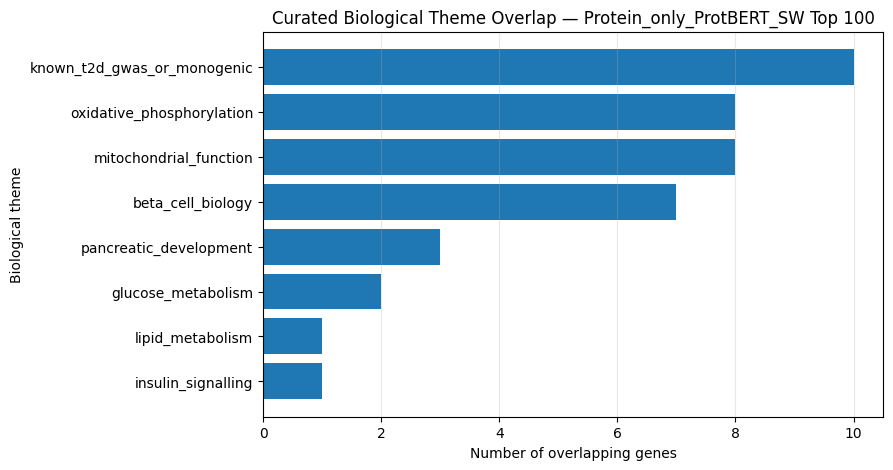

Saved: /content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/figures/phase8_theme_overlap_Protein_only_ProtBERT_SW_top100.png


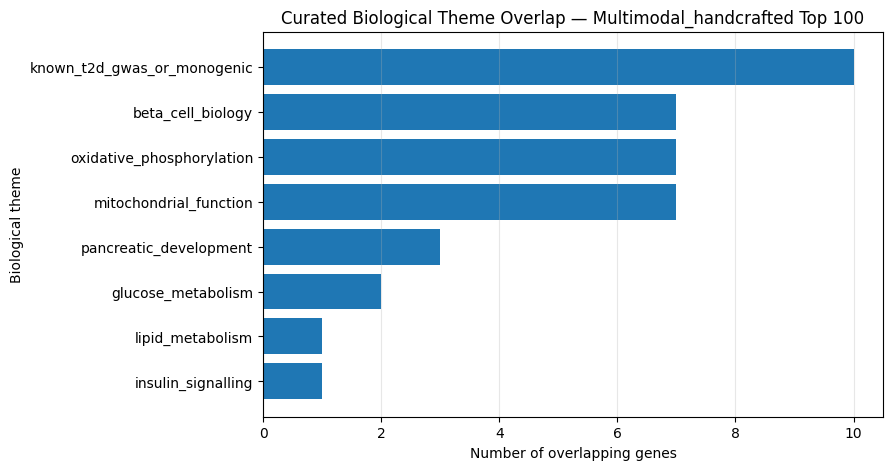

Saved: /content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/figures/phase8_theme_overlap_Multimodal_handcrafted_top100.png


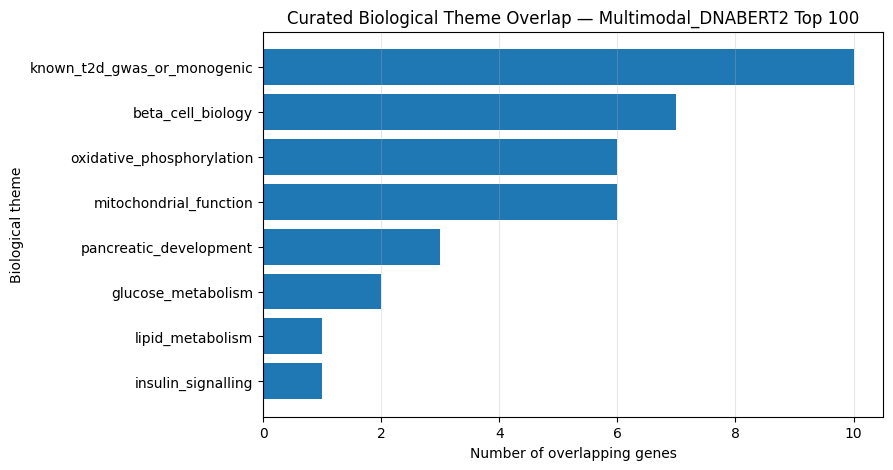

Saved: /content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/figures/phase8_theme_overlap_Multimodal_DNABERT2_top100.png


In [22]:
# ============================================================
# FIGURE: BIOLOGICAL THEME OVERLAP
# ============================================================

def plot_theme_overlap(model_key, top_n=100):
    plot_df = theme_overlap_df[
        (theme_overlap_df["model_key"] == model_key) &
        (theme_overlap_df["top_n"] == top_n)
    ].copy()

    plot_df = plot_df.sort_values("n_overlap", ascending=True)

    plt.figure(figsize=(8, 5))
    plt.barh(plot_df["theme"], plot_df["n_overlap"])
    plt.xlabel("Number of overlapping genes")
    plt.ylabel("Biological theme")
    plt.title(f"Curated Biological Theme Overlap — {model_key} Top {top_n}")
    plt.grid(axis="x", alpha=0.3)

    out_path = FIGURE_DIR / f"phase8_theme_overlap_{model_key}_top{top_n}.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)


for model_key in ["Protein_only_ProtBERT_SW", "Multimodal_handcrafted", "Multimodal_DNABERT2"]:
    plot_theme_overlap(model_key, top_n=100)

In [23]:
# ============================================================
# FIGURE: DNABERT-2 MOVED-IN / MOVED-OUT THEME OVERLAP
# ============================================================

moved_lists_for_plot = []

for top_n in [50, 100]:
    for list_type in ["moved_in", "moved_out"]:
        if list_type == "moved_in":
            p = GENE_LIST_DIR / f"phase8_dnabert2_moved_in_top{top_n}.csv"
            list_label = f"DNABERT2_moved_in_top{top_n}"
        else:
            p = GENE_LIST_DIR / f"phase8_dnabert2_moved_out_top{top_n}.csv"
            list_label = f"DNABERT2_moved_out_top{top_n}"

        df = pd.read_csv(p)
        df["gene_symbol_upper"] = df["gene_symbol"].apply(normalize_gene_symbol)
        gene_set = set(df["gene_symbol_upper"])

        for theme, theme_genes in biological_theme_gene_sets.items():
            theme_set = set([normalize_gene_symbol(g) for g in theme_genes])
            overlap = sorted(list(gene_set & theme_set))

            moved_lists_for_plot.append({
                "top_n": top_n,
                "list_type": list_type,
                "theme": theme,
                "n_overlap": len(overlap),
                "overlap_genes": ";".join(overlap)
            })

moved_theme_df = pd.DataFrame(moved_lists_for_plot)

display(moved_theme_df)

moved_theme_path = RESULT_DIR / "phase8_dnabert2_moved_in_out_theme_overlap.csv"
moved_theme_df.to_csv(moved_theme_path, index=False)

print("Saved:", moved_theme_path)

,top_n,list_type,theme,n_overlap,overlap_genes
0,50,moved_in,insulin_signalling,0,
1,50,moved_in,glucose_metabolism,0,
2,50,moved_in,beta_cell_biology,0,
3,50,moved_in,mitochondrial_function,0,
4,50,moved_in,oxidative_phosphorylation,0,
5,50,moved_in,pancreatic_development,0,
6,50,moved_in,lipid_metabolism,0,
7,50,moved_in,known_t2d_gwas_or_monogenic,0,
8,50,moved_out,insulin_signalling,0,
9,50,moved_out,glucose_metabolism,1,SLC5A1


Saved: /content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/results/phase8_dnabert2_moved_in_out_theme_overlap.csv


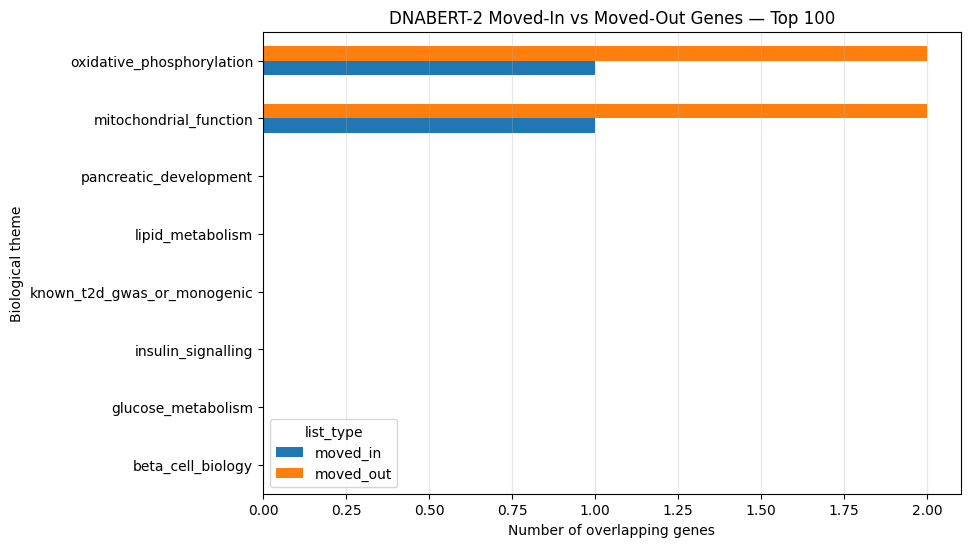

Saved: /content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/figures/phase8_dnabert2_moved_in_out_theme_overlap_top100.png


In [24]:
# Plot moved-in/out for top100
plot_df = moved_theme_df[moved_theme_df["top_n"] == 100].copy()

pivot_plot = plot_df.pivot_table(
    index="theme",
    columns="list_type",
    values="n_overlap",
    aggfunc="first"
).fillna(0)

pivot_plot = pivot_plot.sort_values(
    by=[c for c in pivot_plot.columns],
    ascending=True
)

pivot_plot.plot(kind="barh", figsize=(9, 6))
plt.xlabel("Number of overlapping genes")
plt.ylabel("Biological theme")
plt.title("DNABERT-2 Moved-In vs Moved-Out Genes — Top 100")
plt.grid(axis="x", alpha=0.3)

out_path = FIGURE_DIR / "phase8_dnabert2_moved_in_out_theme_overlap_top100.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

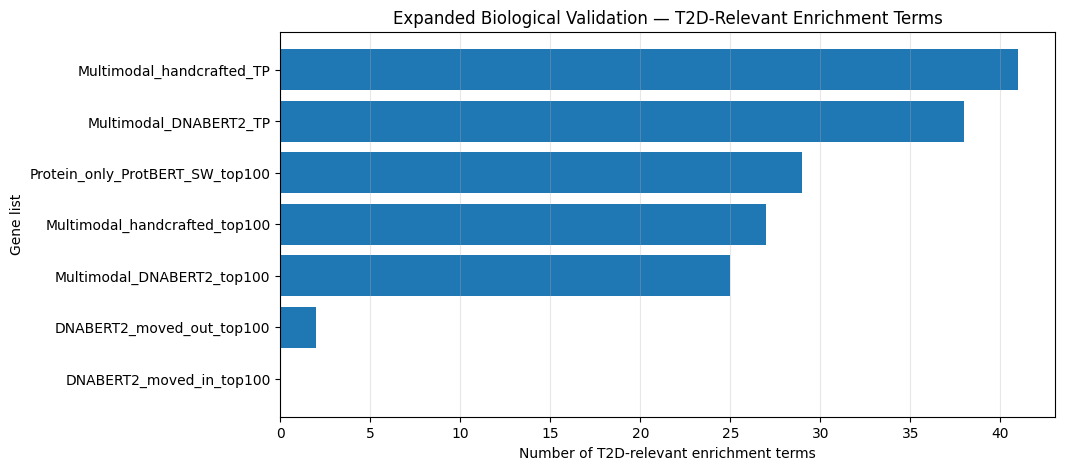

Saved: /content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/figures/phase8_enrichment_summary_t2d_relevant_terms.png


In [25]:
# ============================================================
# FIGURE: ENRICHMENT SUMMARY
# ============================================================

plot_enrich_df = enrichment_summary_df.copy()

# Keep most important lists for readability
keep_patterns = [
    "Protein_only_ProtBERT_SW_top100",
    "Multimodal_handcrafted_top100",
    "Multimodal_DNABERT2_top100",
    "Multimodal_handcrafted_TP",
    "Multimodal_DNABERT2_TP",
    "DNABERT2_moved_in_top100",
    "DNABERT2_moved_out_top100"
]

plot_enrich_df = plot_enrich_df[
    plot_enrich_df["gene_list_name"].isin(keep_patterns)
].copy()

plot_enrich_df = plot_enrich_df.sort_values("n_t2d_relevant_terms", ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(plot_enrich_df["gene_list_name"], plot_enrich_df["n_t2d_relevant_terms"])
plt.xlabel("Number of T2D-relevant enrichment terms")
plt.ylabel("Gene list")
plt.title("Expanded Biological Validation — T2D-Relevant Enrichment Terms")
plt.grid(axis="x", alpha=0.3)

out_path = FIGURE_DIR / "phase8_enrichment_summary_t2d_relevant_terms.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

In [26]:
# ============================================================
# FINAL PHASE 8 SUMMARY TABLES
# ============================================================

# Table 1: Top100 theme summary for key models
table1_theme_top100 = theme_overlap_df[
    (theme_overlap_df["top_n"] == 100) &
    (theme_overlap_df["model_key"].isin([
        "Protein_only_ProtBERT_SW",
        "Multimodal_handcrafted",
        "Multimodal_DNABERT2"
    ]))
].copy()

table1_theme_top100 = table1_theme_top100.sort_values(
    by=["model_key", "n_overlap"],
    ascending=[True, False]
).reset_index(drop=True)

# Table 2: Model top100 enrichment summary
table2_enrichment_key = enrichment_summary_df[
    enrichment_summary_df["gene_list_name"].isin([
        "Protein_only_ProtBERT_SW_top100",
        "Multimodal_handcrafted_top100",
        "Multimodal_DNABERT2_top100",
        "Multimodal_handcrafted_TP",
        "Multimodal_DNABERT2_TP",
        "DNABERT2_moved_in_top100",
        "DNABERT2_moved_out_top100"
    ])
].copy()

# Table 3: DNABERT2 movement summary
table3_dnabert2_movement = moved_summary_df.copy()

# Table 4: Candidate literature evidence table
table4_literature_seed = literature_seed_df.copy()

# Table 5: Top biological genes
table5_top_bio_genes = top_bio_genes_df.copy()

# Save CSVs
tables = {
    "table1_theme_overlap_top100": table1_theme_top100,
    "table2_key_enrichment_summary": table2_enrichment_key,
    "table3_dnabert2_movement_summary": table3_dnabert2_movement,
    "table4_literature_evidence_seed": table4_literature_seed,
    "table5_top100_curated_biological_genes": table5_top_bio_genes,
}

for name, df in tables.items():
    out_path = RESULT_DIR / f"phase8_{name}.csv"
    df.to_csv(out_path, index=False)
    print("Saved:", out_path)

display(table1_theme_top100.head(30))
display(table2_enrichment_key)
display(table3_dnabert2_movement)
display(table4_literature_seed.head(20))

Saved: /content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/results/phase8_table1_theme_overlap_top100.csv
Saved: /content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/results/phase8_table2_key_enrichment_summary.csv
Saved: /content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/results/phase8_table3_dnabert2_movement_summary.csv
Saved: /content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/results/phase8_table4_literature_evidence_seed.csv
Saved: /content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/results/phase8_table5_top100_curated_biological_genes.csv


,model_key,top_n,theme,n_top_genes,n_theme_genes,n_overlap,overlap_fraction_top,overlap_genes
0,Multimodal_DNABERT2,100,known_t2d_gwas_or_monogenic,100,32,10,0.10,CACNA1D;DPP4;GAD1;HHEX;IGF2BP2;INSR;KCNJ11;NEUROD1;PDX1;SLC5A1
1,Multimodal_DNABERT2,100,beta_cell_biology,100,26,7,0.07,CACNA1D;DPP4;GAD1;ISL1;KCNJ11;NEUROD1;PDX1
2,Multimodal_DNABERT2,100,mitochondrial_function,100,52,6,0.06,NDUFA7;NDUFA9;NDUFB1;NDUFB2;NDUFC2;NDUFV1
3,Multimodal_DNABERT2,100,oxidative_phosphorylation,100,25,6,0.06,NDUFA7;NDUFA9;NDUFB1;NDUFB2;NDUFC2;NDUFV1
4,Multimodal_DNABERT2,100,pancreatic_development,100,20,3,0.03,ISL1;NEUROD1;PDX1
5,Multimodal_DNABERT2,100,glucose_metabolism,100,23,2,0.02,SLC5A1;SLC5A2
6,Multimodal_DNABERT2,100,insulin_signalling,100,23,1,0.01,INSR
7,Multimodal_DNABERT2,100,lipid_metabolism,100,20,1,0.01,SCD5
8,Multimodal_handcrafted,100,known_t2d_gwas_or_monogenic,100,32,10,0.10,CACNA1D;DPP4;GAD1;HHEX;IGF2BP2;INSR;KCNJ11;NEUROD1;PDX1;SLC5A1
9,Multimodal_handcrafted,100,beta_cell_biology,100,26,7,0.07,CACNA1D;DPP4;GAD1;ISL1;KCNJ11;NEUROD1;PDX1


,gene_list_name,n_input_genes,n_significant_terms,n_t2d_relevant_terms,best_p_value,top_term,top_t2d_relevant_term,top_matched_groups
0,Multimodal_handcrafted_TP,86,175,41,0.00000,respiratory chain complex I,respiratory chain complex I,mitochondrial_function;oxidative_phosphorylation
1,Multimodal_DNABERT2_TP,88,148,38,0.00000,active monoatomic ion transmembrane transporter activity,NADH dehydrogenase (ubiquinone) activity,mitochondrial_function;oxidative_phosphorylation
3,Protein_only_ProtBERT_SW_top100,100,106,29,0.00000,NADH dehydrogenase (ubiquinone) activity,NADH dehydrogenase (ubiquinone) activity,mitochondrial_function;oxidative_phosphorylation
4,Multimodal_handcrafted_top100,100,103,27,0.00000,NADH dehydrogenase complex,NADH dehydrogenase complex,mitochondrial_function;oxidative_phosphorylation
5,Multimodal_DNABERT2_top100,100,74,25,0.00002,NADH dehydrogenase complex,NADH dehydrogenase complex,mitochondrial_function;oxidative_phosphorylation
7,DNABERT2_moved_out_top100,13,2,2,0.04201,NADH dehydrogenase complex,NADH dehydrogenase complex,mitochondrial_function;oxidative_phosphorylation
15,DNABERT2_moved_in_top100,13,0,0,NaN,None,None,None


,top_n,shared_n,moved_in_to_dnabert2_n,moved_out_from_handcrafted_n,jaccard,shared_genes,moved_in_to_dnabert2_genes,moved_out_from_handcrafted_genes
0,50,39,11,11,0.6393,ACADS;ADCY9;ADRB1;ATP1A2;BCL11B;CACNA1D;CCDC6;CPEB3;DACH1;DNMT3A;DYRK2;ETV1;FAXC;FOXN3;GAD1;GALNT10;HHEX;IGF2BP2;INSR;ISL1;L3MBTL3;MEIS1;MRC2;NDUFB2;NDUFV1;NEUROD1;NFAT5;NT5C2;PAXIP1;PDX1;PPP2R2C;PRDM5;PTPRM;RHBDL3;SCD5;TCF12;TFAP2B;TSHZ3;ZC3H12C,CHRNA1;DDC;EBF2;GALNT3;GLRA1;IGSF21;MAGI1;NCALD;NSD3;PARP8;TUBB4A,DPP4;EIF4E2;GATD3;GRM7;HMG20A;MGAM;NDUFA7;NDUFB1;NDUFB3;RALY;SLC5A1
1,100,87,13,13,0.7699,ACADS;ADCY9;ADRB1;ARF3;ATP1A2;B3GLCT;BCL11B;CACNA1D;CCDC6;CHRNA1;COL23A1;CPEB3;DACH1;DDC;DGKD;DNMT3A;DPP4;DYRK2;EBF2;EIF1;EIF4E2;ELF1;ENPP3;ETV1;FAXC;FGGY;FOXN3;GAD1;GALNT10;GALNT3;GATD3;GLRA1;GNPDA2;GRM7;HAS2;HHEX;HMG20A;IGF2BP2;IGSF21;INSR;ISL1;KCNJ11;KDM2B;KIF2A;L3MBTL3;MAGI1;MAML2;MEIS1;MGAM...,AFAP1L2;ARF5;GPAT4;HCFC2;NDUFA9;PARP8;PELO;PGBD5;SCTR;SLC38A11;TBC1D8;TENT5C;TMEM106B,ARID5B;ATG16L1;EXOC1;ILVBL;MYBL2;NDUFA13;NDUFB3;QSOX1;RALY;RPS19;SMPDL3A;TNIP1;WDR3


,gene_symbol,biological_theme,known_relevance_summary,why_relevant_to_model,literature_reference_to_fill,gene_symbol_upper,Multimodal_handcrafted_rank,Multimodal_handcrafted_score,Multimodal_handcrafted_true_label,Multimodal_handcrafted_error_type,Multimodal_DNABERT2_rank,Multimodal_DNABERT2_score,Multimodal_DNABERT2_true_label,Multimodal_DNABERT2_error_type,Protein_only_ProtBERT_SW_rank,Protein_only_ProtBERT_SW_score,Protein_only_ProtBERT_SW_true_label,Protein_only_ProtBERT_SW_error_type
0,INSR,insulin_signalling,Insulin receptor; central mediator of insulin signalling and glucose homeostasis.,High-ranked gene supports insulin signalling relevance.,,INSR,6,0.8175,1,TP,6,0.8328,1,TP,13,0.7805,1,TP
1,PDX1,beta_cell_biology;pancreatic_development,Key pancreatic transcription factor involved in beta-cell identity and insulin gene regulation.,Supports beta-cell and pancreatic development biology.,,PDX1,48,0.7070,1,TP,47,0.7017,1,TP,72,0.6705,1,TP
2,NEUROD1,beta_cell_biology;pancreatic_development;known_t2d_gwas_or_monogenic,Transcription factor involved in pancreatic endocrine differentiation and insulin regulation.,Supports beta-cell biology and diabetes-associated transcriptional regulation.,,NEUROD1,5,0.8185,1,TP,39,0.7195,1,TP,8,0.7903,1,TP
3,HHEX,known_t2d_gwas_or_monogenic;pancreatic_development,Known T2D-associated locus implicated in pancreatic development and beta-cell function.,Supports known T2D genetic association signal.,,HHEX,14,0.7984,1,TP,26,0.7533,1,TP,3,0.8146,1,TP
4,IGF2BP2,known_t2d_gwas_or_monogenic,Known T2D-associated gene from genetic association studies.,Supports disease-gene association plausibility.,,IGF2BP2,25,0.7645,1,TP,50,0.6880,1,TP,36,0.7211,1,TP
5,DPP4,beta_cell_biology;known_t2d_gwas_or_monogenic,Dipeptidyl peptidase-4; relevant to incretin biology and diabetes drug-target pathways.,Supports therapeutic and metabolic relevance.,,DPP4,39,0.7289,1,TP,57,0.6765,1,TP,74,0.6670,1,TP
6,CACNA1D,beta_cell_biology;known_t2d_gwas_or_monogenic,Voltage-gated calcium channel subunit; calcium influx is important for insulin secretion.,Supports insulin secretion and beta-cell excitability.,,CACNA1D,13,0.7985,1,TP,2,0.8604,1,TP,14,0.7754,1,TP
7,GAD1,beta_cell_biology;known_t2d_gwas_or_monogenic,Glutamate decarboxylase; related to pancreatic endocrine biology and diabetes-associated immune/metabolic contexts.,Supports endocrine/beta-cell-related signal.,,GAD1,7,0.8134,1,TP,5,0.8365,1,TP,19,0.7621,1,TP
8,SLC5A1,glucose_metabolism;known_t2d_gwas_or_monogenic,Sodium/glucose cotransporter family member; relevant to glucose transport biology.,Supports glucose metabolism/transport theme.,,SLC5A1,20,0.7724,1,TP,74,0.6508,1,TP,51,0.6980,1,TP
9,SCD5,lipid_metabolism;known_t2d_gwas_or_monogenic,Stearoyl-CoA desaturase family member; relevant to lipid metabolism.,Supports lipid metabolism connection to T2D.,,SCD5,36,0.7419,1,TP,31,0.7455,1,TP,41,0.7148,1,TP


In [27]:
# ============================================================
# EXPORT PHASE 8 EXCEL WORKBOOK
# ============================================================

excel_path = EXCEL_DIR / "phase8_expanded_biological_validation_tables.xlsx"

excel_tables = {
    "Theme_Top100": table1_theme_top100,
    "Key_Enrichment": table2_enrichment_key,
    "DNABERT2_Movement": table3_dnabert2_movement,
    "Literature_Seed": table4_literature_seed,
    "Top_Bio_Genes": table5_top_bio_genes,
    "Theme_Compare": pivot_theme_df,
    "Moved_Theme": moved_theme_df,
    "Top_Overlap": overlap_df,
    "T2D_Terms": t2d_relevant_terms_df,
}

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    for sheet_name, df in excel_tables.items():
        df.to_excel(writer, sheet_name=sheet_name[:31], index=False)

print("Saved Excel:", excel_path)

Saved Excel: /content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/excel/phase8_expanded_biological_validation_tables.xlsx


In [28]:
# ============================================================
# AUTO-GENERATE PHASE 8 REPORT SUMMARY
# ============================================================

# Pull key summary values
hand_top100_enrich = enrichment_summary_df[
    enrichment_summary_df["gene_list_name"] == "Multimodal_handcrafted_top100"
]

dna_top100_enrich = enrichment_summary_df[
    enrichment_summary_df["gene_list_name"] == "Multimodal_DNABERT2_top100"
]

protein_top100_enrich = enrichment_summary_df[
    enrichment_summary_df["gene_list_name"] == "Protein_only_ProtBERT_SW_top100"
]

def get_enrich_stat(df, col, default="NA"):
    if df.empty:
        return default
    return df.iloc[0][col]

hand_sig = get_enrich_stat(hand_top100_enrich, "n_significant_terms", 0)
hand_t2d = get_enrich_stat(hand_top100_enrich, "n_t2d_relevant_terms", 0)
hand_top_term = get_enrich_stat(hand_top100_enrich, "top_t2d_relevant_term", "NA")

dna_sig = get_enrich_stat(dna_top100_enrich, "n_significant_terms", 0)
dna_t2d = get_enrich_stat(dna_top100_enrich, "n_t2d_relevant_terms", 0)
dna_top_term = get_enrich_stat(dna_top100_enrich, "top_t2d_relevant_term", "NA")

protein_sig = get_enrich_stat(protein_top100_enrich, "n_significant_terms", 0)
protein_t2d = get_enrich_stat(protein_top100_enrich, "n_t2d_relevant_terms", 0)
protein_top_term = get_enrich_stat(protein_top100_enrich, "top_t2d_relevant_term", "NA")

# Movement values
movement_top100 = moved_summary_df[moved_summary_df["top_n"] == 100].iloc[0]
shared100 = int(movement_top100["shared_n"])
moved_in100 = int(movement_top100["moved_in_to_dnabert2_n"])
moved_out100 = int(movement_top100["moved_out_from_handcrafted_n"])
jaccard100 = float(movement_top100["jaccard"])

report_text = f"""
# Phase 8 — Expanded Biological Validation Report

## Objective

Phase 8 expanded the biological validation beyond the original top-50 analysis. The aim was to examine additional top-ranked genes, compare biological themes across protein-only, handcrafted multimodal, and DNABERT-2 multimodal models, and investigate how DNABERT-2 changes the top-ranked gene lists.

## Top-100 Biological Validation

The top-100 gene lists were extracted for three key models:

1. Protein-only ProtBERT-SW
2. Multimodal handcrafted: ProtBERT-SW + K3/K4/Basic
3. Multimodal DNABERT-2: ProtBERT-SW + DNABERT-2

## Enrichment Summary

Protein-only top 100:
- Significant terms: {protein_sig}
- T2D-relevant terms: {protein_t2d}
- Top T2D-relevant term: {protein_top_term}

Handcrafted multimodal top 100:
- Significant terms: {hand_sig}
- T2D-relevant terms: {hand_t2d}
- Top T2D-relevant term: {hand_top_term}

DNABERT-2 multimodal top 100:
- Significant terms: {dna_sig}
- T2D-relevant terms: {dna_t2d}
- Top T2D-relevant term: {dna_top_term}

## DNABERT-2 Movement Analysis

Between handcrafted multimodal and DNABERT-2 multimodal top-100 lists:

- Shared top-100 genes: {shared100}
- DNABERT-2 moved-in genes: {moved_in100}
- Handcrafted moved-out genes: {moved_out100}
- Jaccard overlap: {jaccard100:.4f}

This analysis helps explain whether DNABERT-2 improves ranking by preserving the same biological candidates or by shifting toward a different biological signal.

## Interpretation

If the handcrafted multimodal top-100 list shows stronger oxidative phosphorylation, mitochondrial, insulin, glucose, beta-cell, or pancreatic development support, this reinforces its role as the official biologically validated model.

If DNABERT-2 moved-in genes show different biological themes, this supports the interpretation that DNABERT-2 captures different regulatory sequence signals. This may explain why DNABERT-2 improves ROC-AUC while showing weaker enrichment in the original top-50 validation.

## Output

Phase 8 generated:

- Top-100 ranked gene tables
- Curated biological theme overlap tables
- DNABERT-2 moved-in and moved-out gene tables
- Expanded g:Profiler enrichment results
- Candidate literature evidence seed table
- Theme overlap figures
- Enrichment summary figures
"""

report_path = REPORT_DIR / "phase8_expanded_biological_validation_summary.md"

with open(report_path, "w") as f:
    f.write(report_text)

print(report_text)
print("Saved report:", report_path)


# Phase 8 — Expanded Biological Validation Report

## Objective

Phase 8 expanded the biological validation beyond the original top-50 analysis. The aim was to examine additional top-ranked genes, compare biological themes across protein-only, handcrafted multimodal, and DNABERT-2 multimodal models, and investigate how DNABERT-2 changes the top-ranked gene lists.

## Top-100 Biological Validation

The top-100 gene lists were extracted for three key models:

1. Protein-only ProtBERT-SW
2. Multimodal handcrafted: ProtBERT-SW + K3/K4/Basic
3. Multimodal DNABERT-2: ProtBERT-SW + DNABERT-2

## Enrichment Summary

Protein-only top 100:
- Significant terms: 106
- T2D-relevant terms: 29
- Top T2D-relevant term: NADH dehydrogenase (ubiquinone) activity

Handcrafted multimodal top 100:
- Significant terms: 103
- T2D-relevant terms: 27
- Top T2D-relevant term: NADH dehydrogenase complex

DNABERT-2 multimodal top 100:
- Significant terms: 74
- T2D-relevant terms: 25
- Top T2D-relevant term: NADH 

In [29]:
# ============================================================
# LIST PHASE 8 OUTPUT FILES
# ============================================================

print("=== RESULT FILES ===")
for p in sorted(RESULT_DIR.glob("*")):
    print(p)

print("\n=== GENE LIST FILES ===")
for p in sorted(GENE_LIST_DIR.glob("*")):
    print(p)

print("\n=== ENRICHMENT FILES ===")
for p in sorted(ENRICHMENT_DIR.glob("*")):
    print(p)

print("\n=== FIGURE FILES ===")
for p in sorted(FIGURE_DIR.glob("*")):
    print(p)

print("\n=== EXCEL FILES ===")
for p in sorted(EXCEL_DIR.glob("*")):
    print(p)

print("\n=== REPORT FILES ===")
for p in sorted(REPORT_DIR.glob("*")):
    print(p)

=== RESULT FILES ===
/content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/results/phase8_all_expanded_enrichment_results.csv
/content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/results/phase8_all_ranked_predictions_Genomic_only_K3K4Basic.csv
/content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/results/phase8_all_ranked_predictions_Multimodal_DNABERT2.csv
/content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/results/phase8_all_ranked_predictions_Multimodal_handcrafted.csv
/content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/results/phase8_all_ranked_predictions_Protein_only_ProtBERT_SW.csv
/content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/results/phase8_annotated_ranked_predictions_Genomic_only_K3K4Basic.csv
/content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/results/phase8_an

In [30]:
display(table1_theme_top100)
display(table2_enrichment_key)
display(table3_dnabert2_movement)
display(table4_literature_seed)
display(pivot_theme_df)
display(moved_theme_df)

,model_key,top_n,theme,n_top_genes,n_theme_genes,n_overlap,overlap_fraction_top,overlap_genes
0,Multimodal_DNABERT2,100,known_t2d_gwas_or_monogenic,100,32,10,0.10,CACNA1D;DPP4;GAD1;HHEX;IGF2BP2;INSR;KCNJ11;NEUROD1;PDX1;SLC5A1
1,Multimodal_DNABERT2,100,beta_cell_biology,100,26,7,0.07,CACNA1D;DPP4;GAD1;ISL1;KCNJ11;NEUROD1;PDX1
2,Multimodal_DNABERT2,100,mitochondrial_function,100,52,6,0.06,NDUFA7;NDUFA9;NDUFB1;NDUFB2;NDUFC2;NDUFV1
3,Multimodal_DNABERT2,100,oxidative_phosphorylation,100,25,6,0.06,NDUFA7;NDUFA9;NDUFB1;NDUFB2;NDUFC2;NDUFV1
4,Multimodal_DNABERT2,100,pancreatic_development,100,20,3,0.03,ISL1;NEUROD1;PDX1
5,Multimodal_DNABERT2,100,glucose_metabolism,100,23,2,0.02,SLC5A1;SLC5A2
6,Multimodal_DNABERT2,100,insulin_signalling,100,23,1,0.01,INSR
7,Multimodal_DNABERT2,100,lipid_metabolism,100,20,1,0.01,SCD5
8,Multimodal_handcrafted,100,known_t2d_gwas_or_monogenic,100,32,10,0.10,CACNA1D;DPP4;GAD1;HHEX;IGF2BP2;INSR;KCNJ11;NEUROD1;PDX1;SLC5A1
9,Multimodal_handcrafted,100,beta_cell_biology,100,26,7,0.07,CACNA1D;DPP4;GAD1;ISL1;KCNJ11;NEUROD1;PDX1


,gene_list_name,n_input_genes,n_significant_terms,n_t2d_relevant_terms,best_p_value,top_term,top_t2d_relevant_term,top_matched_groups
0,Multimodal_handcrafted_TP,86,175,41,0.00000,respiratory chain complex I,respiratory chain complex I,mitochondrial_function;oxidative_phosphorylation
1,Multimodal_DNABERT2_TP,88,148,38,0.00000,active monoatomic ion transmembrane transporter activity,NADH dehydrogenase (ubiquinone) activity,mitochondrial_function;oxidative_phosphorylation
3,Protein_only_ProtBERT_SW_top100,100,106,29,0.00000,NADH dehydrogenase (ubiquinone) activity,NADH dehydrogenase (ubiquinone) activity,mitochondrial_function;oxidative_phosphorylation
4,Multimodal_handcrafted_top100,100,103,27,0.00000,NADH dehydrogenase complex,NADH dehydrogenase complex,mitochondrial_function;oxidative_phosphorylation
5,Multimodal_DNABERT2_top100,100,74,25,0.00002,NADH dehydrogenase complex,NADH dehydrogenase complex,mitochondrial_function;oxidative_phosphorylation
7,DNABERT2_moved_out_top100,13,2,2,0.04201,NADH dehydrogenase complex,NADH dehydrogenase complex,mitochondrial_function;oxidative_phosphorylation
15,DNABERT2_moved_in_top100,13,0,0,NaN,None,None,None


,top_n,shared_n,moved_in_to_dnabert2_n,moved_out_from_handcrafted_n,jaccard,shared_genes,moved_in_to_dnabert2_genes,moved_out_from_handcrafted_genes
0,50,39,11,11,0.6393,ACADS;ADCY9;ADRB1;ATP1A2;BCL11B;CACNA1D;CCDC6;CPEB3;DACH1;DNMT3A;DYRK2;ETV1;FAXC;FOXN3;GAD1;GALNT10;HHEX;IGF2BP2;INSR;ISL1;L3MBTL3;MEIS1;MRC2;NDUFB2;NDUFV1;NEUROD1;NFAT5;NT5C2;PAXIP1;PDX1;PPP2R2C;PRDM5;PTPRM;RHBDL3;SCD5;TCF12;TFAP2B;TSHZ3;ZC3H12C,CHRNA1;DDC;EBF2;GALNT3;GLRA1;IGSF21;MAGI1;NCALD;NSD3;PARP8;TUBB4A,DPP4;EIF4E2;GATD3;GRM7;HMG20A;MGAM;NDUFA7;NDUFB1;NDUFB3;RALY;SLC5A1
1,100,87,13,13,0.7699,ACADS;ADCY9;ADRB1;ARF3;ATP1A2;B3GLCT;BCL11B;CACNA1D;CCDC6;CHRNA1;COL23A1;CPEB3;DACH1;DDC;DGKD;DNMT3A;DPP4;DYRK2;EBF2;EIF1;EIF4E2;ELF1;ENPP3;ETV1;FAXC;FGGY;FOXN3;GAD1;GALNT10;GALNT3;GATD3;GLRA1;GNPDA2;GRM7;HAS2;HHEX;HMG20A;IGF2BP2;IGSF21;INSR;ISL1;KCNJ11;KDM2B;KIF2A;L3MBTL3;MAGI1;MAML2;MEIS1;MGAM...,AFAP1L2;ARF5;GPAT4;HCFC2;NDUFA9;PARP8;PELO;PGBD5;SCTR;SLC38A11;TBC1D8;TENT5C;TMEM106B,ARID5B;ATG16L1;EXOC1;ILVBL;MYBL2;NDUFA13;NDUFB3;QSOX1;RALY;RPS19;SMPDL3A;TNIP1;WDR3


,gene_symbol,biological_theme,known_relevance_summary,why_relevant_to_model,literature_reference_to_fill,gene_symbol_upper,Multimodal_handcrafted_rank,Multimodal_handcrafted_score,Multimodal_handcrafted_true_label,Multimodal_handcrafted_error_type,Multimodal_DNABERT2_rank,Multimodal_DNABERT2_score,Multimodal_DNABERT2_true_label,Multimodal_DNABERT2_error_type,Protein_only_ProtBERT_SW_rank,Protein_only_ProtBERT_SW_score,Protein_only_ProtBERT_SW_true_label,Protein_only_ProtBERT_SW_error_type
0,INSR,insulin_signalling,Insulin receptor; central mediator of insulin signalling and glucose homeostasis.,High-ranked gene supports insulin signalling relevance.,,INSR,6,0.8175,1,TP,6,0.8328,1,TP,13,0.7805,1,TP
1,PDX1,beta_cell_biology;pancreatic_development,Key pancreatic transcription factor involved in beta-cell identity and insulin gene regulation.,Supports beta-cell and pancreatic development biology.,,PDX1,48,0.7070,1,TP,47,0.7017,1,TP,72,0.6705,1,TP
2,NEUROD1,beta_cell_biology;pancreatic_development;known_t2d_gwas_or_monogenic,Transcription factor involved in pancreatic endocrine differentiation and insulin regulation.,Supports beta-cell biology and diabetes-associated transcriptional regulation.,,NEUROD1,5,0.8185,1,TP,39,0.7195,1,TP,8,0.7903,1,TP
3,HHEX,known_t2d_gwas_or_monogenic;pancreatic_development,Known T2D-associated locus implicated in pancreatic development and beta-cell function.,Supports known T2D genetic association signal.,,HHEX,14,0.7984,1,TP,26,0.7533,1,TP,3,0.8146,1,TP
4,IGF2BP2,known_t2d_gwas_or_monogenic,Known T2D-associated gene from genetic association studies.,Supports disease-gene association plausibility.,,IGF2BP2,25,0.7645,1,TP,50,0.6880,1,TP,36,0.7211,1,TP
5,DPP4,beta_cell_biology;known_t2d_gwas_or_monogenic,Dipeptidyl peptidase-4; relevant to incretin biology and diabetes drug-target pathways.,Supports therapeutic and metabolic relevance.,,DPP4,39,0.7289,1,TP,57,0.6765,1,TP,74,0.6670,1,TP
6,CACNA1D,beta_cell_biology;known_t2d_gwas_or_monogenic,Voltage-gated calcium channel subunit; calcium influx is important for insulin secretion.,Supports insulin secretion and beta-cell excitability.,,CACNA1D,13,0.7985,1,TP,2,0.8604,1,TP,14,0.7754,1,TP
7,GAD1,beta_cell_biology;known_t2d_gwas_or_monogenic,Glutamate decarboxylase; related to pancreatic endocrine biology and diabetes-associated immune/metabolic contexts.,Supports endocrine/beta-cell-related signal.,,GAD1,7,0.8134,1,TP,5,0.8365,1,TP,19,0.7621,1,TP
8,SLC5A1,glucose_metabolism;known_t2d_gwas_or_monogenic,Sodium/glucose cotransporter family member; relevant to glucose transport biology.,Supports glucose metabolism/transport theme.,,SLC5A1,20,0.7724,1,TP,74,0.6508,1,TP,51,0.6980,1,TP
9,SCD5,lipid_metabolism;known_t2d_gwas_or_monogenic,Stearoyl-CoA desaturase family member; relevant to lipid metabolism.,Supports lipid metabolism connection to T2D.,,SCD5,36,0.7419,1,TP,31,0.7455,1,TP,41,0.7148,1,TP


model_key,top_n,theme,Multimodal_DNABERT2,Multimodal_handcrafted,delta_DNABERT2_minus_handcrafted
0,50,insulin_signalling,1,1,0
1,50,lipid_metabolism,1,1,0
2,50,pancreatic_development,3,3,0
3,50,beta_cell_biology,5,6,-1
4,50,glucose_metabolism,0,1,-1
5,50,known_t2d_gwas_or_monogenic,7,9,-2
6,50,mitochondrial_function,2,5,-3
7,50,oxidative_phosphorylation,2,5,-3
8,100,beta_cell_biology,7,7,0
9,100,glucose_metabolism,2,2,0


,top_n,list_type,theme,n_overlap,overlap_genes
0,50,moved_in,insulin_signalling,0,
1,50,moved_in,glucose_metabolism,0,
2,50,moved_in,beta_cell_biology,0,
3,50,moved_in,mitochondrial_function,0,
4,50,moved_in,oxidative_phosphorylation,0,
5,50,moved_in,pancreatic_development,0,
6,50,moved_in,lipid_metabolism,0,
7,50,moved_in,known_t2d_gwas_or_monogenic,0,
8,50,moved_out,insulin_signalling,0,
9,50,moved_out,glucose_metabolism,1,SLC5A1
